<br><hr><br>
# --- BAGIAN 1: 01_EDA_PM25_ERA5.ipynb ---
<br>

# FASE 1: Exploratory Data Analysis (EDA)
## Prediksi PM2.5 di Kota Bandung Menggunakan LSTM dengan Interpretasi SHAP
**Kerja Praktik-PRSDI BRIN 2026**

---

Notebook ini melakukan eksplorasi awal terhadap dua dataset utama:
1. **Data ERA5** 11 variabel meteorologi satelit (2022-2026)
2. **Data Sensor PM2.5** Sensor low-cost OpenAQ/PurpleAir di Bandung

**Tujuan EDA:**
- Memahami karakteristik dan distribusi setiap variabel
- Mendeteksi anomali, outlier, dan missing values
- Menemukan pola diurnal (per jam) dan musiman (kemarau vs hujan)
- Mengukur korelasi antara variabel cuaca ERA5 dengan konsentrasi PM2.5


## 1. Import Library & Konfigurasi


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi Plotting
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

# Folder output untuk menyimpan grafik
OUTPUT_DIR = r'/content/drive/MyDrive/KP_BRIN/data/eda_plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("✅ Library berhasil di-import!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Library berhasil di-import!


## 2. Load & Inspeksi Data

### 2.1 Data ERA5 (Meteorologi Satelit)
Data reanalisis iklim global dari Copernicus ECMWF yang mencakup 11 variabel cuaca per jam untuk koordinat Bandung.


In [ ]:
# Load ERA5
era5 = pd.read_csv(r'/content/drive/MyDrive/KP_BRIN/data/raw/era5/era5_bandung_2022_2026.csv')
era5['waktu'] = pd.to_datetime(era5['waktu'])
era5 = era5.drop(columns=['number'])  # kolom konstan 0, tidak berguna
era5 = era5.set_index('waktu')

print(f"Shape     : {era5.shape}")
print(f"Periode   : {era5.index.min()} → {era5.index.max()}")
print(f"Missing   : {era5.isnull().sum().sum()}")
print(f"\nVariabel ({len(era5.columns)}):")
for col in era5.columns:
    print(f"  • {col}")

era5.head()


Shape     : (38688, 11)
Periode   : 2022-01-01 00:00:00 → 2026-05-31 23:00:00
Missing   : 0

Variabel (11):
  • tinggi_lapisan_batas_m
  • ozon_kolom_kg_m2
  • uap_air_kolom_kg_m2
  • tutupan_awan_01
  • suhu_2m_C
  • titik_embun_C
  • tekanan_hPa
  • curah_hujan_mm
  • kecepatan_angin_kmh
  • arah_angin_derajat
  • kelembapan_persen


,tinggi_lapisan_batas_m,ozon_kolom_kg_m2,uap_air_kolom_kg_m2,tutupan_awan_01,suhu_2m_C,titik_embun_C,tekanan_hPa,curah_hujan_mm,kecepatan_angin_kmh,arah_angin_derajat,kelembapan_persen
waktu,,,,,,,,,,,
2022-01-01 00:00:00,94.10977,0.005528,36.279686,0.746964,20.403107,18.826630,896.16570,0.001192,2.947840,210.58253,90.675090
2022-01-01 01:00:00,376.50415,0.005532,36.322945,0.923782,21.270172,18.511475,896.85250,0.033617,3.137140,267.33240,84.287360
2022-01-01 02:00:00,616.59300,0.005535,36.970770,0.989807,24.411652,18.397675,897.18243,0.075340,4.483315,264.56247,69.181946
2022-01-01 03:00:00,803.53660,0.005541,37.802788,0.999451,24.724976,18.537445,897.14680,0.112295,6.065242,258.50323,68.494490
2022-01-01 04:00:00,1113.49100,0.005535,38.877945,1.000000,25.201874,19.148804,896.78296,0.006914,6.290211,271.72348,69.165130


In [ ]:
# Statistik deskriptif ERA5
era5.describe().round(3)


,tinggi_lapisan_batas_m,ozon_kolom_kg_m2,uap_air_kolom_kg_m2,tutupan_awan_01,suhu_2m_C,titik_embun_C,tekanan_hPa,curah_hujan_mm,kecepatan_angin_kmh,arah_angin_derajat,kelembapan_persen
count,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000,38688.000
mean,302.598,0.005,36.332,0.829,21.905,19.023,895.914,0.409,3.383,187.456,84.691
std,355.508,0.000,7.334,0.241,2.430,1.352,1.544,0.979,2.096,97.669,11.633
min,12.358,0.005,9.932,0.000,14.817,9.316,890.443,0.000,0.007,0.002,34.475
25%,48.617,0.005,31.761,0.729,20.064,18.451,894.859,0.001,1.900,133.097,77.039
50%,105.915,0.005,38.143,0.960,21.266,19.231,895.947,0.049,3.005,184.178,89.180
75%,498.758,0.006,41.825,0.998,23.780,19.878,897.005,0.290,4.354,266.668,93.865
max,2327.436,0.006,51.299,1.000,29.459,23.219,901.091,14.684,19.504,359.982,100.010


### 2.2 Data Sensor PM2.5 (Ground Station)
Data konsentrasi PM2.5 dari sensor low-cost (PurpleAir) di wilayah Bandung, diakses melalui OpenAQ.


In [ ]:
# Load Sensor PM2.5
sensor = pd.read_csv(r'/content/drive/MyDrive/KP_BRIN/data/raw/purpleair/hourly_all_sensors.csv')
sensor['datetime'] = pd.to_datetime(sensor['datetime'], utc=True)
sensor['datetime'] = sensor['datetime'].dt.tz_convert('Asia/Jakarta')

print(f"Shape     : {sensor.shape}")
print(f"Periode   : {sensor['datetime'].min()} → {sensor['datetime'].max()}")
print(f"Sensor ID : {sensor['sensor_id'].unique()}")
print(f"\nJumlah data per sensor:")
print(sensor['sensor_id'].value_counts().to_string())
print(f"\nMissing values:")
print(sensor.isnull().sum().to_string())

sensor.head()


Shape     : (25076, 8)
Periode   : 2022-11-09 10:00:00+07:00 → 2026-05-31 06:00:00+07:00
Sensor ID : [121867 238875]

Jumlah data per sensor:
sensor_id
121867    16541
238875     8535

Missing values:
time_stamp        0
humidity       2593
temperature    2593
pressure       2593
pm2.5_alt         2
pm2.5_cf_1        0
sensor_id         0
datetime          0


,time_stamp,humidity,temperature,pressure,pm2.5_alt,pm2.5_cf_1,sensor_id,datetime
0,1668474000,57.0,93.0,1010.24,3.2,4.0,121867,2022-11-15 08:00:00+07:00
1,1668488400,58.0,93.0,1007.95,1.5,1.0,121867,2022-11-15 12:00:00+07:00
2,1668495600,62.0,90.0,1006.63,1.1,0.2,121867,2022-11-15 14:00:00+07:00
3,1668502800,66.0,87.0,1007.61,3.7,4.3,121867,2022-11-15 16:00:00+07:00
4,1668477600,60.0,91.0,1010.09,1.1,0.2,121867,2022-11-15 09:00:00+07:00


In [ ]:
# Statistik deskriptif sensor
sensor.describe().round(3)


,time_stamp,humidity,temperature,pressure,pm2.5_alt,pm2.5_cf_1,sensor_id
count,2.507600e+04,22483.000,22483.000,22483.000,25074.000,25076.000,25076.000
mean,1.728249e+09,58.171,85.167,932.000,31.557,64.582,161692.462
std,3.622835e+07,10.491,7.840,78.435,26.759,189.049,55443.240
min,1.667963e+09,18.000,64.000,-117.480,0.000,0.000,121867.000
25%,1.692165e+09,52.000,79.000,921.910,10.400,17.800,121867.000
50%,1.729301e+09,60.000,85.000,926.700,25.200,40.500,121867.000
75%,1.760066e+09,66.000,90.000,1010.200,46.900,77.500,238875.000
max,1.780182e+09,100.000,374.000,1017.120,573.800,2698.400,238875.000


## 3. Perbandingan Dua Sensor PM2.5

Terdapat dua sensor di Bandung. Kita perlu menentukan sensor mana yang paling stabil dan memiliki data terlengkap untuk digunakan sebagai **ground truth** dalam pemodelan.


In [ ]:
# Pisahkan data per sensor
sensor_121867 = sensor[sensor['sensor_id'] == 121867].copy()
sensor_238875 = sensor[sensor['sensor_id'] == 238875].copy()

print("=" * 50)
print("SENSOR 121867 (Utama)")
print("=" * 50)
print(f"  Jumlah data : {len(sensor_121867):,}")
print(f"  Periode     : {sensor_121867['datetime'].min()} → {sensor_121867['datetime'].max()}")
print(f"  PM2.5 Mean  : {sensor_121867['pm2.5_alt'].mean():.2f} µg/m³")
print(f"  PM2.5 Median: {sensor_121867['pm2.5_alt'].median():.2f} µg/m³")
print(f"  PM2.5 Max   : {sensor_121867['pm2.5_alt'].max():.2f} µg/m³")

print()
print("=" * 50)
print("SENSOR 238875 (Pembanding)")
print("=" * 50)
print(f"  Jumlah data : {len(sensor_238875):,}")
print(f"  Periode     : {sensor_238875['datetime'].min()} → {sensor_238875['datetime'].max()}")
print(f"  PM2.5 Mean  : {sensor_238875['pm2.5_alt'].mean():.2f} µg/m³")
print(f"  PM2.5 Median: {sensor_238875['pm2.5_alt'].median():.2f} µg/m³")
print(f"  PM2.5 Max   : {sensor_238875['pm2.5_alt'].max():.2f} µg/m³")


SENSOR 121867 (Utama)
  Jumlah data : 16,541
  Periode     : 2022-11-09 10:00:00+07:00 → 2026-05-31 06:00:00+07:00
  PM2.5 Mean  : 29.12 µg/m³
  PM2.5 Median: 20.30 µg/m³
  PM2.5 Max   : 573.80 µg/m³

SENSOR 238875 (Pembanding)
  Jumlah data : 8,535
  Periode     : 2025-05-07 15:00:00+07:00 → 2026-05-31 06:00:00+07:00
  PM2.5 Mean  : 36.28 µg/m³
  PM2.5 Median: 33.80 µg/m³
  PM2.5 Max   : 134.70 µg/m³


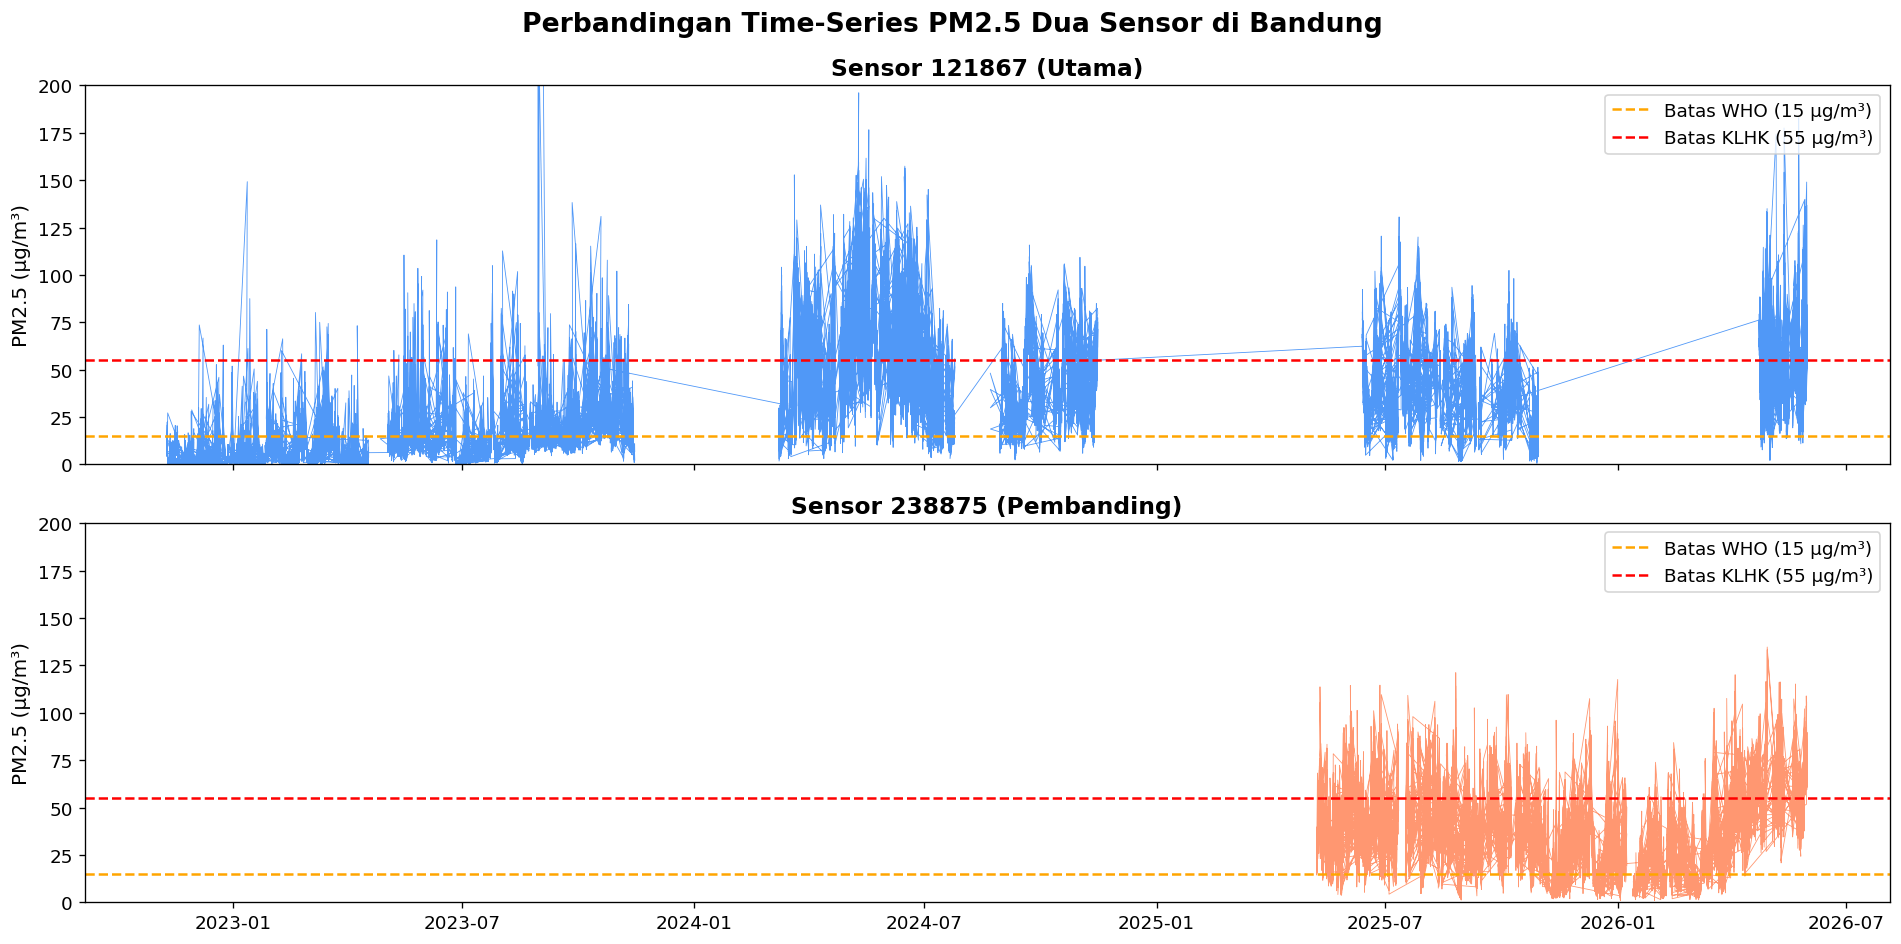

In [ ]:
# Visualisasi perbandingan time-series dua sensor
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Perbandingan Time-Series PM2.5 Dua Sensor di Bandung', fontsize=16, fontweight='bold')

axes[0].plot(sensor_121867['datetime'], sensor_121867['pm2.5_alt'],
             color='#066CF4', linewidth=0.5, alpha=0.7)
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Sensor 121867 (Utama)')
axes[0].axhline(y=15, color='orange', linestyle='--', linewidth=1.5, label='Batas WHO (15 µg/m³)')
axes[0].axhline(y=55, color='red', linestyle='--', linewidth=1.5, label='Batas KLHK (55 µg/m³)')
axes[0].legend(loc='upper right')
axes[0].set_ylim(0, 200)

axes[1].plot(sensor_238875['datetime'], sensor_238875['pm2.5_alt'],
             color='#FF6B35', linewidth=0.5, alpha=0.7)
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_title('Sensor 238875 (Pembanding)')
axes[1].axhline(y=15, color='orange', linestyle='--', linewidth=1.5, label='Batas WHO (15 µg/m³)')
axes[1].axhline(y=55, color='red', linestyle='--', linewidth=1.5, label='Batas KLHK (55 µg/m³)')
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 200)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '01_perbandingan_dua_sensor.png'))
plt.show()


## 4. Analisis Sensor Utama (121867)

Berdasarkan perbandingan di atas, **Sensor 121867** dipilih sebagai sensor utama karena:
- Memiliki data lebih lengkap (~16.500 vs ~8.500 data points)
- Periode waktu lebih panjang

### 4.1 Deteksi Outlier & Anomali


In [ ]:
# Siapkan data sensor utama
pm25 = sensor_121867[['datetime', 'pm2.5_alt', 'humidity', 'temperature', 'pressure']].copy()
pm25 = pm25.rename(columns={'pm2.5_alt': 'pm25'})
pm25 = pm25.set_index('datetime')
pm25.index = pm25.index.tz_localize(None)  # hapus timezone untuk merge nanti

# Deteksi outlier menggunakan metode IQR
Q1 = pm25['pm25'].quantile(0.25)
Q3 = pm25['pm25'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR
outliers = pm25[(pm25['pm25'] < lower_bound) | (pm25['pm25'] > upper_bound)]

print("Deteksi Outlier PM2.5 (Metode IQR)")
print("=" * 40)
print(f"  Q1 (25%)     : {Q1:.2f} µg/m³")
print(f"  Q3 (75%)     : {Q3:.2f} µg/m³")
print(f"  IQR          : {IQR:.2f}")
print(f"  Batas bawah  : {lower_bound:.2f} µg/m³")
print(f"  Batas atas   : {upper_bound:.2f} µg/m³")
print(f"  Jumlah outlier: {len(outliers)} ({len(outliers)/len(pm25)*100:.1f}%)")

# Cek anomali sensor fisik
print(f"\n⚠️ Anomali Suhu (>100°F)    : {len(pm25[pm25['temperature'] > 100])} data points")
print(f"⚠️ Anomali Tekanan (<0 hPa) : {len(pm25[pm25['pressure'] < 0])} data points")


Deteksi Outlier PM2.5 (Metode IQR)
  Q1 (25%)     : 7.60 µg/m³
  Q3 (75%)     : 42.95 µg/m³
  IQR          : 35.35
  Batas bawah  : 0.00 µg/m³
  Batas atas   : 95.98 µg/m³
  Jumlah outlier: 529 (3.2%)

⚠️ Anomali Suhu (>100°F)    : 563 data points
⚠️ Anomali Tekanan (<0 hPa) : 1 data points


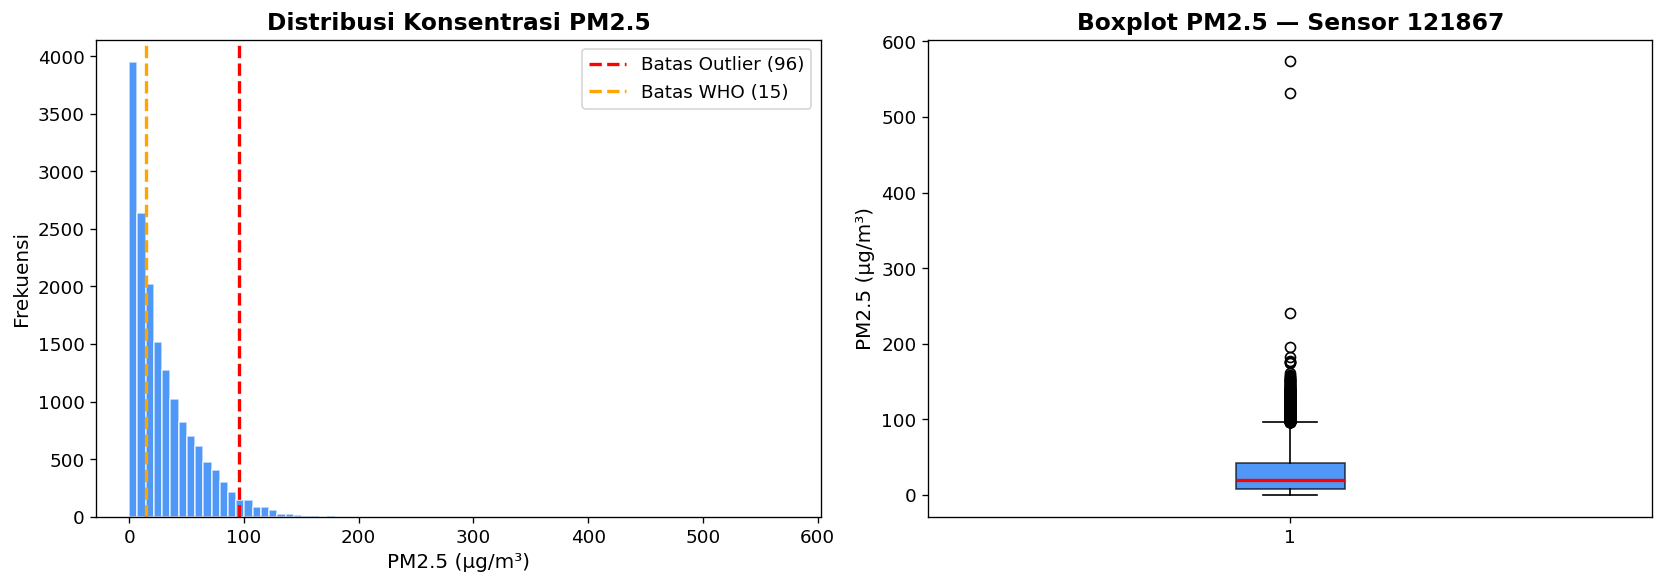

In [ ]:
# Visualisasi distribusi PM2.5 dengan batas outlier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(pm25['pm25'], bins=80, color='#066CF4', alpha=0.7, edgecolor='white')
axes[0].axvline(x=upper_bound, color='red', linestyle='--', linewidth=2, label=f'Batas Outlier ({upper_bound:.0f})')
axes[0].axvline(x=15, color='orange', linestyle='--', linewidth=2, label='Batas WHO (15)')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Konsentrasi PM2.5')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(pm25['pm25'].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#066CF4', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_title('Boxplot PM2.5 — Sensor 121867')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '02_distribusi_pm25.png'))
plt.show()


## 5. Distribusi 11 Variabel Meteorologi ERA5

Visualisasi distribusi untuk memahami karakteristik setiap variabel cuaca satelit.


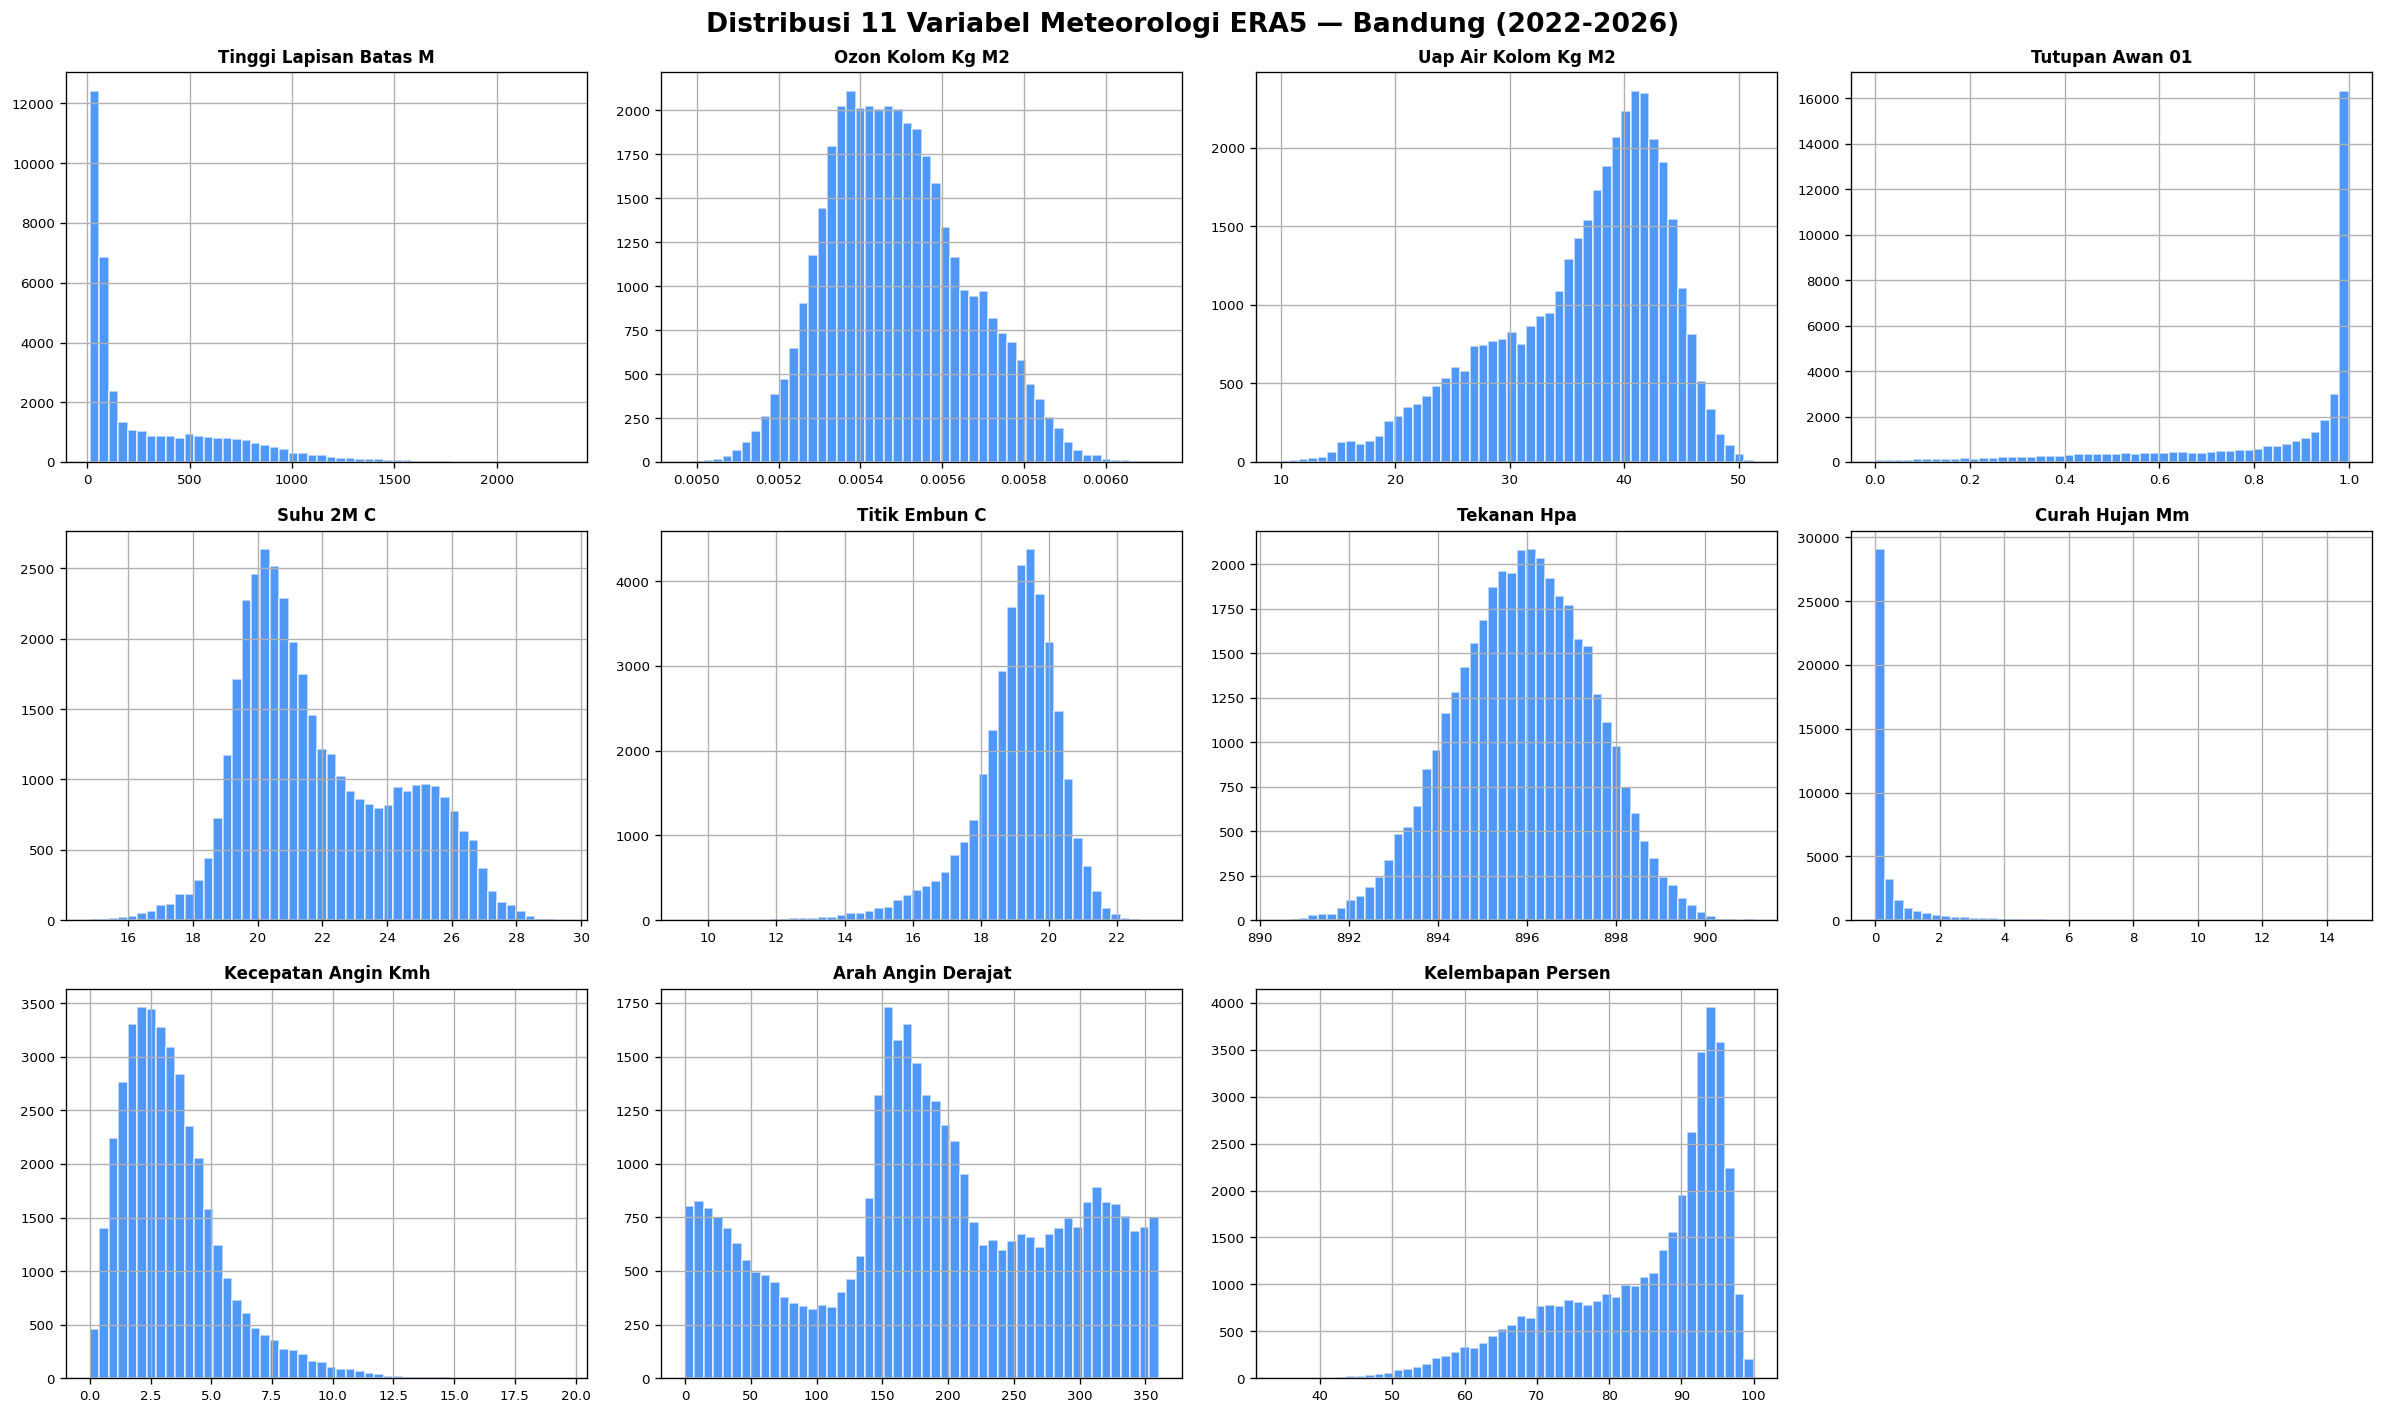

In [ ]:
era5_vars = [
    'tinggi_lapisan_batas_m', 'ozon_kolom_kg_m2', 'uap_air_kolom_kg_m2',
    'tutupan_awan_01', 'suhu_2m_C', 'titik_embun_C',
    'tekanan_hPa', 'curah_hujan_mm', 'kecepatan_angin_kmh',
    'arah_angin_derajat', 'kelembapan_persen'
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Distribusi 11 Variabel Meteorologi ERA5 — Bandung (2022-2026)',
             fontsize=16, fontweight='bold')

for i, var in enumerate(era5_vars):
    ax = axes[i // 4, i % 4]
    era5[var].hist(bins=50, ax=ax, color='#066CF4', alpha=0.7, edgecolor='white')
    ax.set_title(var.replace('_', ' ').title(), fontsize=10)
    ax.tick_params(labelsize=8)

# Hapus subplot kosong
axes[2, 3].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '03_distribusi_era5.png'))
plt.show()


## 6. Time-Series Variabel Kunci ERA5

Visualisasi 6 variabel meteorologi terpenting sepanjang periode 2022–2026.
Area oranye menandai **musim kemarau** (Juni–September).


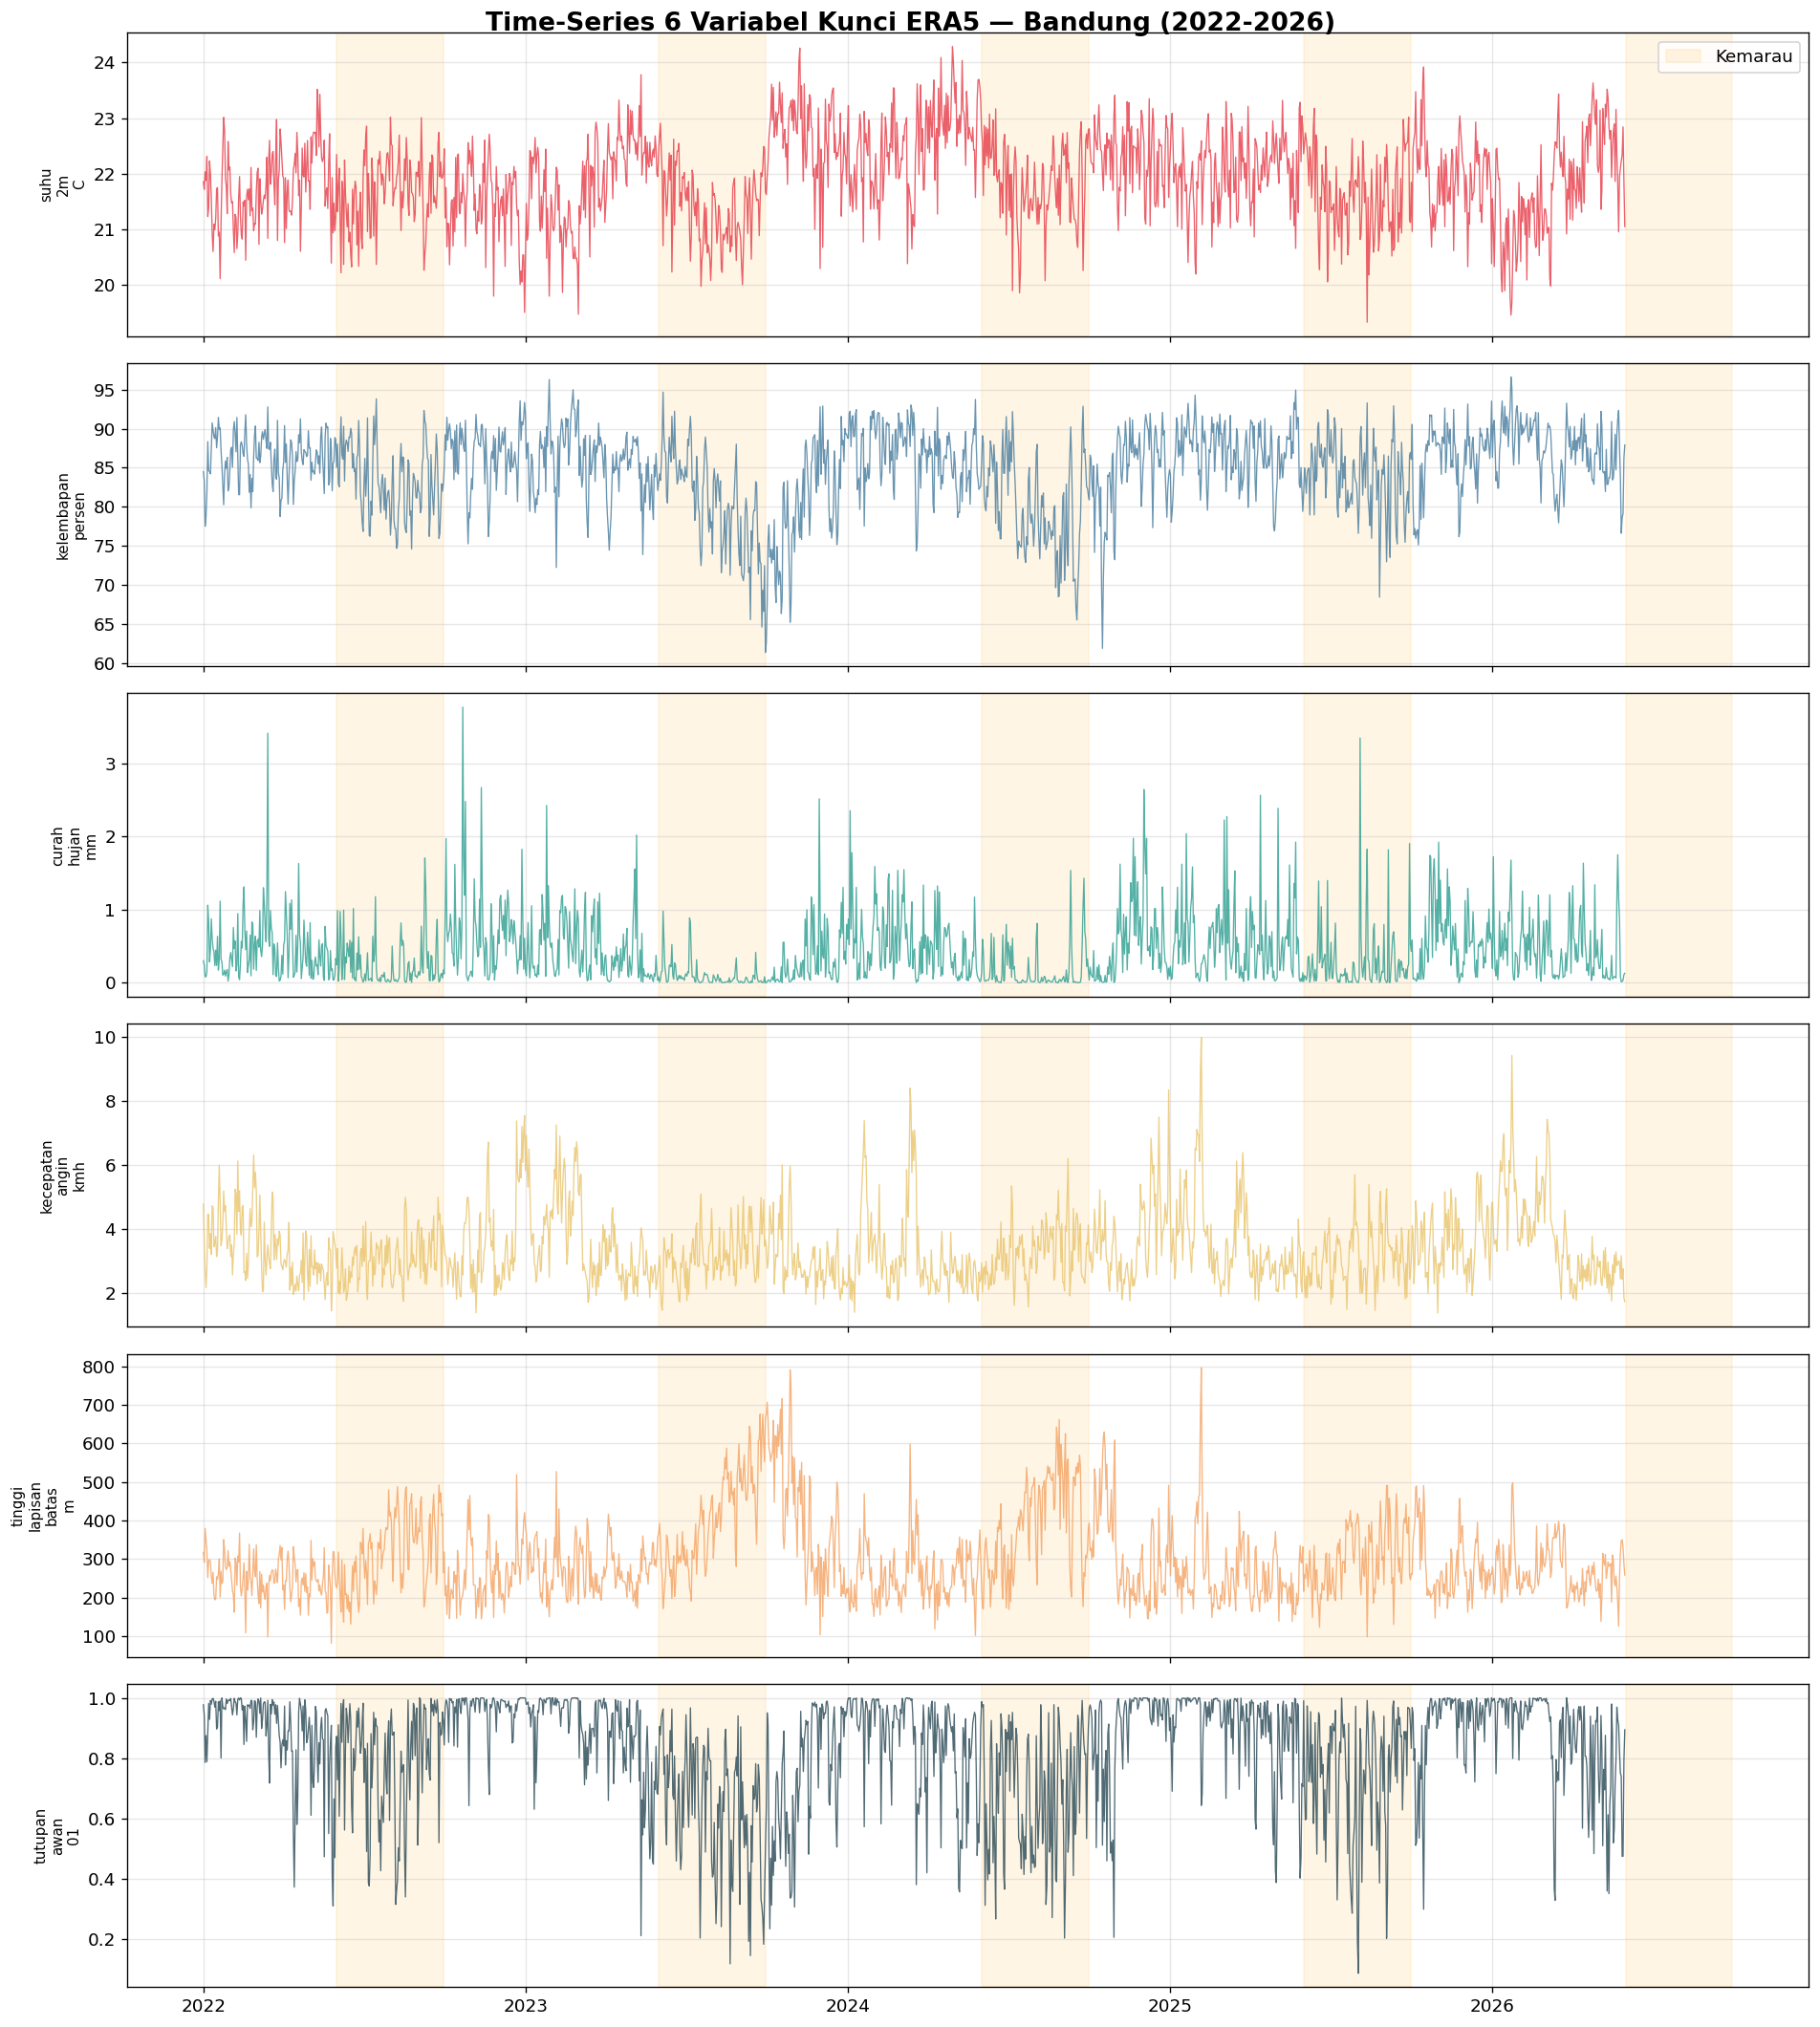

In [ ]:
key_vars = ['suhu_2m_C', 'kelembapan_persen', 'curah_hujan_mm',
            'kecepatan_angin_kmh', 'tinggi_lapisan_batas_m', 'tutupan_awan_01']

fig, axes = plt.subplots(len(key_vars), 1, figsize=(16, 18), sharex=True)
fig.suptitle('Time-Series 6 Variabel Kunci ERA5 — Bandung (2022-2026)',
             fontsize=16, fontweight='bold')

colors = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261', '#264653']

for i, var in enumerate(key_vars):
    daily = era5[var].resample('D').mean()
    axes[i].plot(daily.index, daily.values, color=colors[i], linewidth=0.8, alpha=0.8)
    axes[i].set_ylabel(var.replace('_', '\n'), fontsize=9)
    axes[i].grid(True, alpha=0.3)

    # Tandai musim kemarau (Jun-Sep)
    for year in range(2022, 2027):
        try:
            start = pd.Timestamp(f'{year}-06-01')
            end = pd.Timestamp(f'{year}-09-30')
            axes[i].axvspan(start, end, alpha=0.1, color='orange',
                           label='Kemarau' if year == 2022 else '')
        except:
            pass

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '04_timeseries_era5_kunci.png'))
plt.show()


## 7. Pola Diurnal PM2.5 (Per Jam)

Menganalisis variasi konsentrasi PM2.5 berdasarkan jam dalam sehari.
Studi BRIN (2026) menunjukkan bahwa PM2.5 di Bandung memuncak pada:
- **Pagi hari** (06:00–08:00 WIB) — jam berangkat kerja/sekolah
- **Malam hari** (18:00–23:00 WIB) — jam pulang + stabilitas atmosfer


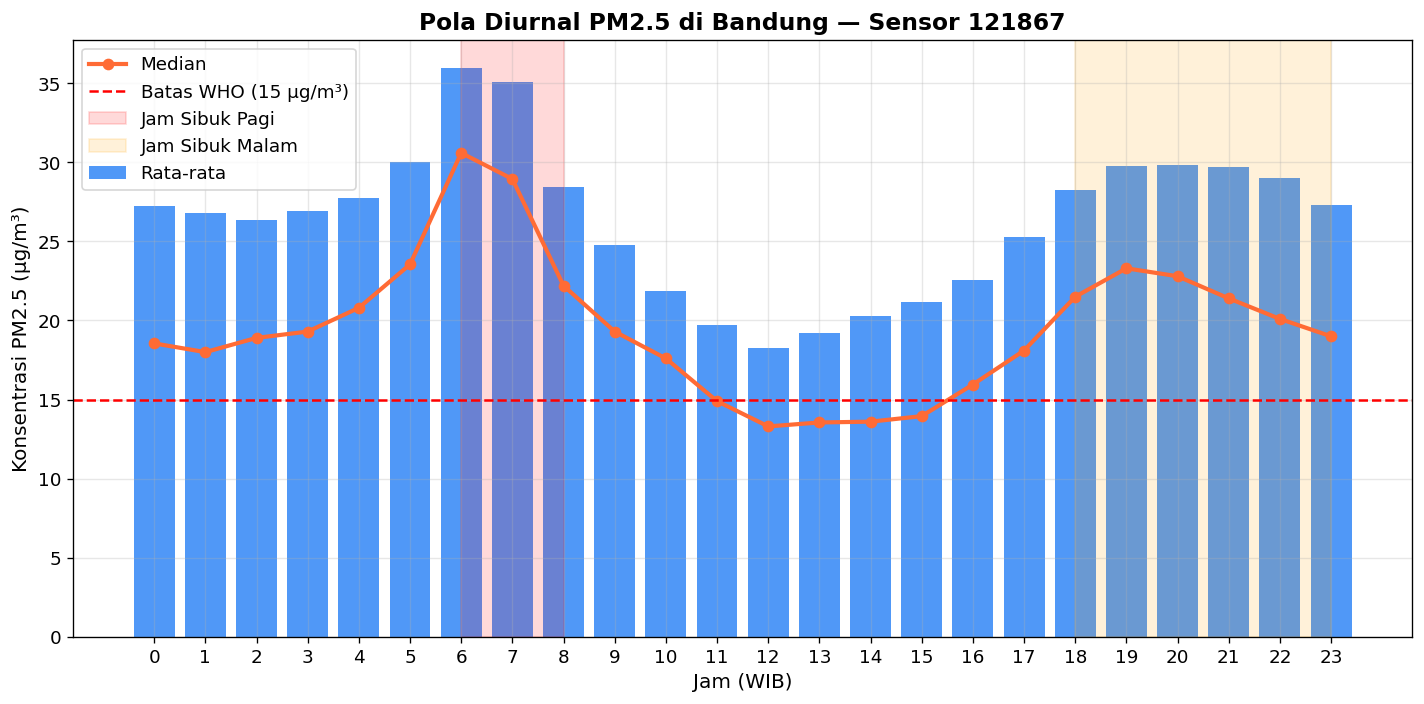

Jam dengan PM2.5 TERTINGGI : 6:00 WIB (35.97 µg/m³)
Jam dengan PM2.5 TERENDAH  : 12:00 WIB (18.26 µg/m³)


In [ ]:
# Bersihkan outlier untuk analisis yang lebih akurat
pm25_clean = pm25[pm25['pm25'] < upper_bound].copy()
pm25_clean['hour'] = pm25_clean.index.hour

hourly_stats = pm25_clean.groupby('hour')['pm25'].agg(['mean', 'median', 'std'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(hourly_stats.index, hourly_stats['mean'], color='#066CF4', alpha=0.7, label='Rata-rata')
ax.plot(hourly_stats.index, hourly_stats['median'], color='#FF6B35', linewidth=2.5,
        marker='o', markersize=6, label='Median')
ax.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Batas WHO (15 µg/m³)')
ax.axvspan(6, 8, alpha=0.15, color='red', label='Jam Sibuk Pagi')
ax.axvspan(18, 23, alpha=0.15, color='orange', label='Jam Sibuk Malam')
ax.set_xlabel('Jam (WIB)')
ax.set_ylabel('Konsentrasi PM2.5 (µg/m³)')
ax.set_title('Pola Diurnal PM2.5 di Bandung — Sensor 121867', fontweight='bold')
ax.set_xticks(range(24))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '05_pola_diurnal_pm25.png'))
plt.show()

print(f"Jam dengan PM2.5 TERTINGGI : {hourly_stats['mean'].idxmax()}:00 WIB "
      f"({hourly_stats['mean'].max():.2f} µg/m³)")
print(f"Jam dengan PM2.5 TERENDAH  : {hourly_stats['mean'].idxmin()}:00 WIB "
      f"({hourly_stats['mean'].min():.2f} µg/m³)")


## 8. Pola Musiman PM2.5 (Per Bulan)

Membandingkan konsentrasi PM2.5 antara **musim kemarau** (Juni–September, bar merah)
dan **musim hujan** (Oktober–Mei, bar biru).


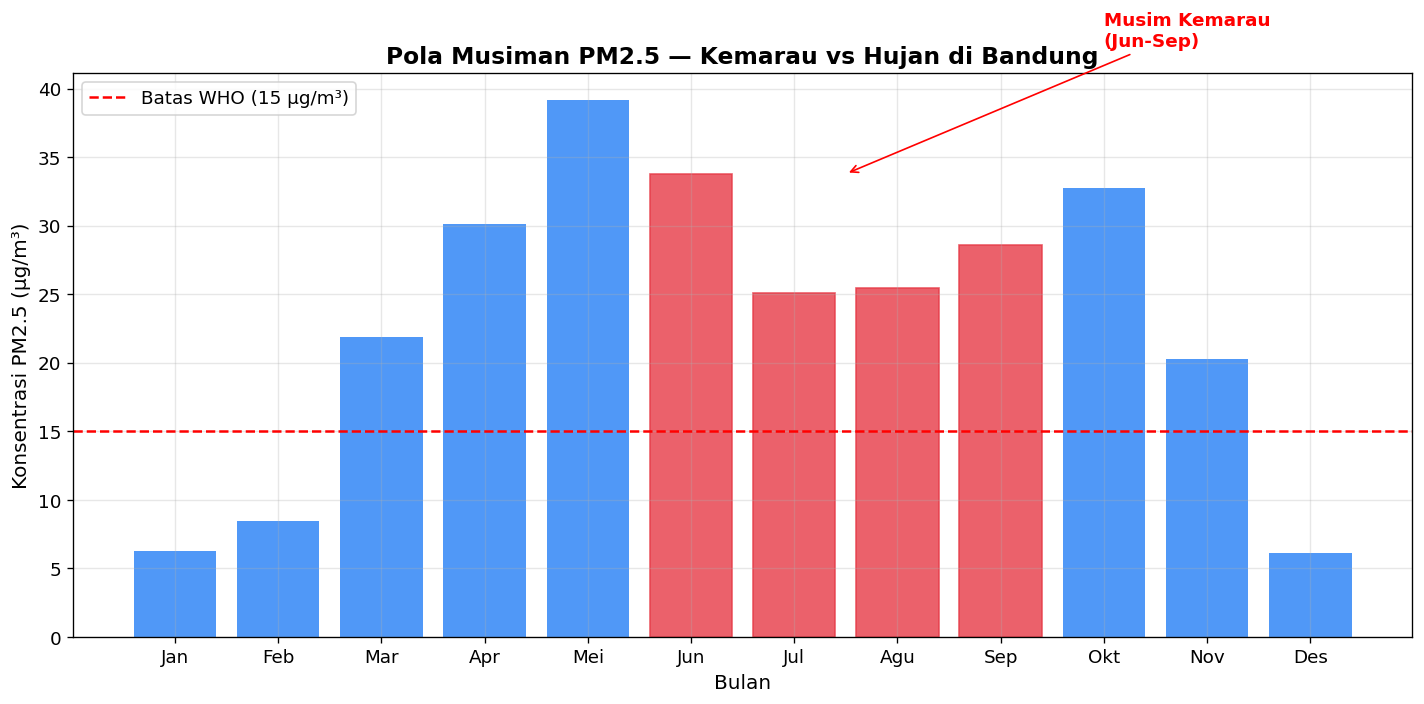


Rata-rata PM2.5 Musim KEMARAU (Jun-Sep) : 28.22 µg/m³
Rata-rata PM2.5 Musim HUJAN (Des-Mar)    : 12.51 µg/m³
Peningkatan saat Kemarau                 : 125.6%


In [ ]:
pm25_clean['month'] = pm25_clean.index.month
monthly_stats = pm25_clean.groupby('month')['pm25'].agg(['mean', 'median', 'std'])

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun',
               'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(monthly_stats.index, monthly_stats['mean'], color='#066CF4', alpha=0.7)

# Warnai musim kemarau dengan warna merah
for i, bar in enumerate(bars):
    if monthly_stats.index[i] in [6, 7, 8, 9]:
        bar.set_color('#E63946')
        bar.set_alpha(0.8)

ax.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Batas WHO (15 µg/m³)')
ax.set_xlabel('Bulan')
ax.set_ylabel('Konsentrasi PM2.5 (µg/m³)')
ax.set_title('Pola Musiman PM2.5 — Kemarau vs Hujan di Bandung', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.legend()
ax.grid(True, alpha=0.3)

# Anotasi musim kemarau
ax.annotate('Musim Kemarau\n(Jun-Sep)',
            xy=(7.5, monthly_stats.loc[6:9, 'mean'].max()),
            xytext=(10, monthly_stats['mean'].max() * 1.1),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '06_pola_musiman_pm25.png'))
plt.show()

kemarau_mean = pm25_clean[pm25_clean['month'].isin([6,7,8,9])]['pm25'].mean()
hujan_mean = pm25_clean[pm25_clean['month'].isin([12,1,2,3])]['pm25'].mean()
print(f"\nRata-rata PM2.5 Musim KEMARAU (Jun-Sep) : {kemarau_mean:.2f} µg/m³")
print(f"Rata-rata PM2.5 Musim HUJAN (Des-Mar)    : {hujan_mean:.2f} µg/m³")
print(f"Peningkatan saat Kemarau                 : {((kemarau_mean/hujan_mean)-1)*100:.1f}%")


## 9. Analisis Korelasi: ERA5 vs PM2.5

Menghitung korelasi Pearson antara setiap variabel meteorologi ERA5 dengan konsentrasi PM2.5.
Ini adalah langkah krusial untuk memahami **variabel cuaca mana yang paling mempengaruhi polusi**.


In [ ]:
# MERGE + FILTER PERIODE BERSIH (Mempertahankan Time-Series Kontinu)
# Menggunakan how='right' agar mengikuti timeline ERA5 yang 100% lengkap
merged = pm25_clean[['pm25']].join(era5, how='right')
merged = merged.sort_index().loc['2022-11-01':'2023-11-30']

print(f"Data setelah di-merge (Waktu Kontinu): {len(merged):,} baris")
print(f"Periode: {merged.index.min()} → {merged.index.max()}")
print(f"Jumlah baris PM2.5 yang kosong (NaN) : {merged['pm25'].isnull().sum():,} baris")
display(merged.head())

# Hitung korelasi (Pandas otomatis mengabaikan NaN saat menghitung korelasi)
corr = merged.corr()['pm25'].drop('pm25').sort_values(ascending=False)

print(f"\n{'='*55}")
print(f"{'Variabel ERA5':<35} {'Korelasi':>8} {'Kekuatan':>10}")
print(f"{'='*55}")
for var, val in corr.items():
    direction = "↑" if val > 0 else "↓"
    strength = "KUAT" if abs(val) > 0.3 else "SEDANG" if abs(val) > 0.15 else "LEMAH"
    print(f"  {direction} {var:<32} {val:+.4f}   {strength}")
print(f"{'='*55}")

# Simpan dataset bersih
# merged.to_csv(r'D:\Kuliah Praktik\KP BRIN\data\processed\merged_clean_nov22_nov23.csv')
# print(f"\n✅ Disimpan: data/processed/merged_clean_nov22_nov23.csv")

Data setelah di-merge (Waktu Kontinu): 9,480 baris
Periode: 2022-11-01 00:00:00 → 2023-11-30 23:00:00
Jumlah baris PM2.5 yang kosong (NaN) : 1,103 baris


,pm25,tinggi_lapisan_batas_m,ozon_kolom_kg_m2,uap_air_kolom_kg_m2,tutupan_awan_01,suhu_2m_C,titik_embun_C,tekanan_hPa,curah_hujan_mm,kecepatan_angin_kmh,arah_angin_derajat,kelembapan_persen
waktu,,,,,,,,,,,,
2022-11-01 00:00:00,NaN,92.72803,0.005751,27.488464,1.000000,20.373688,18.461700,896.73070,0.000000,2.918084,164.70277,88.789734
2022-11-01 01:00:00,NaN,367.36963,0.005754,27.103363,1.000000,21.000336,18.531830,897.15630,0.000715,2.515868,145.01494,85.804260
2022-11-01 02:00:00,NaN,653.92163,0.005749,26.778046,1.000000,25.041595,19.185242,897.03015,0.037670,1.811486,153.49089,69.987360
2022-11-01 03:00:00,NaN,862.48440,0.005740,27.552444,1.000000,25.678680,18.822845,896.67800,0.111341,0.017975,30.48330,65.879350
2022-11-01 04:00:00,NaN,951.28955,0.005734,29.051926,0.998886,25.804047,18.834320,896.32760,0.289440,1.558655,340.18820,65.438330



Variabel ERA5                       Korelasi   Kekuatan
  ↑ tinggi_lapisan_batas_m           +0.3216   KUAT
  ↑ suhu_2m_C                        +0.2474   SEDANG
  ↑ tekanan_hPa                      +0.1633   SEDANG
  ↑ kecepatan_angin_kmh              +0.0319   LEMAH
  ↓ curah_hujan_mm                   -0.0263   LEMAH
  ↓ ozon_kolom_kg_m2                 -0.1207   LEMAH
  ↓ arah_angin_derajat               -0.1769   SEDANG
  ↓ titik_embun_C                    -0.1773   SEDANG
  ↓ uap_air_kolom_kg_m2              -0.2711   SEDANG
  ↓ tutupan_awan_01                  -0.2721   SEDANG
  ↓ kelembapan_persen                -0.3155   KUAT


In [ ]:
merged.to_csv(r'/content/drive/MyDrive/KP_BRIN/data/raw/merged_pm25_era5v3.csv', index=True)
print("Data merged berhasil disimpan ke '/content/drive/MyDrive/KP_BRIN/data/raw/merged_pm25_era5v3.csv'")

Data merged berhasil disimpan ke '/content/drive/MyDrive/KP_BRIN/data/raw/merged_pm25_era5v3.csv'


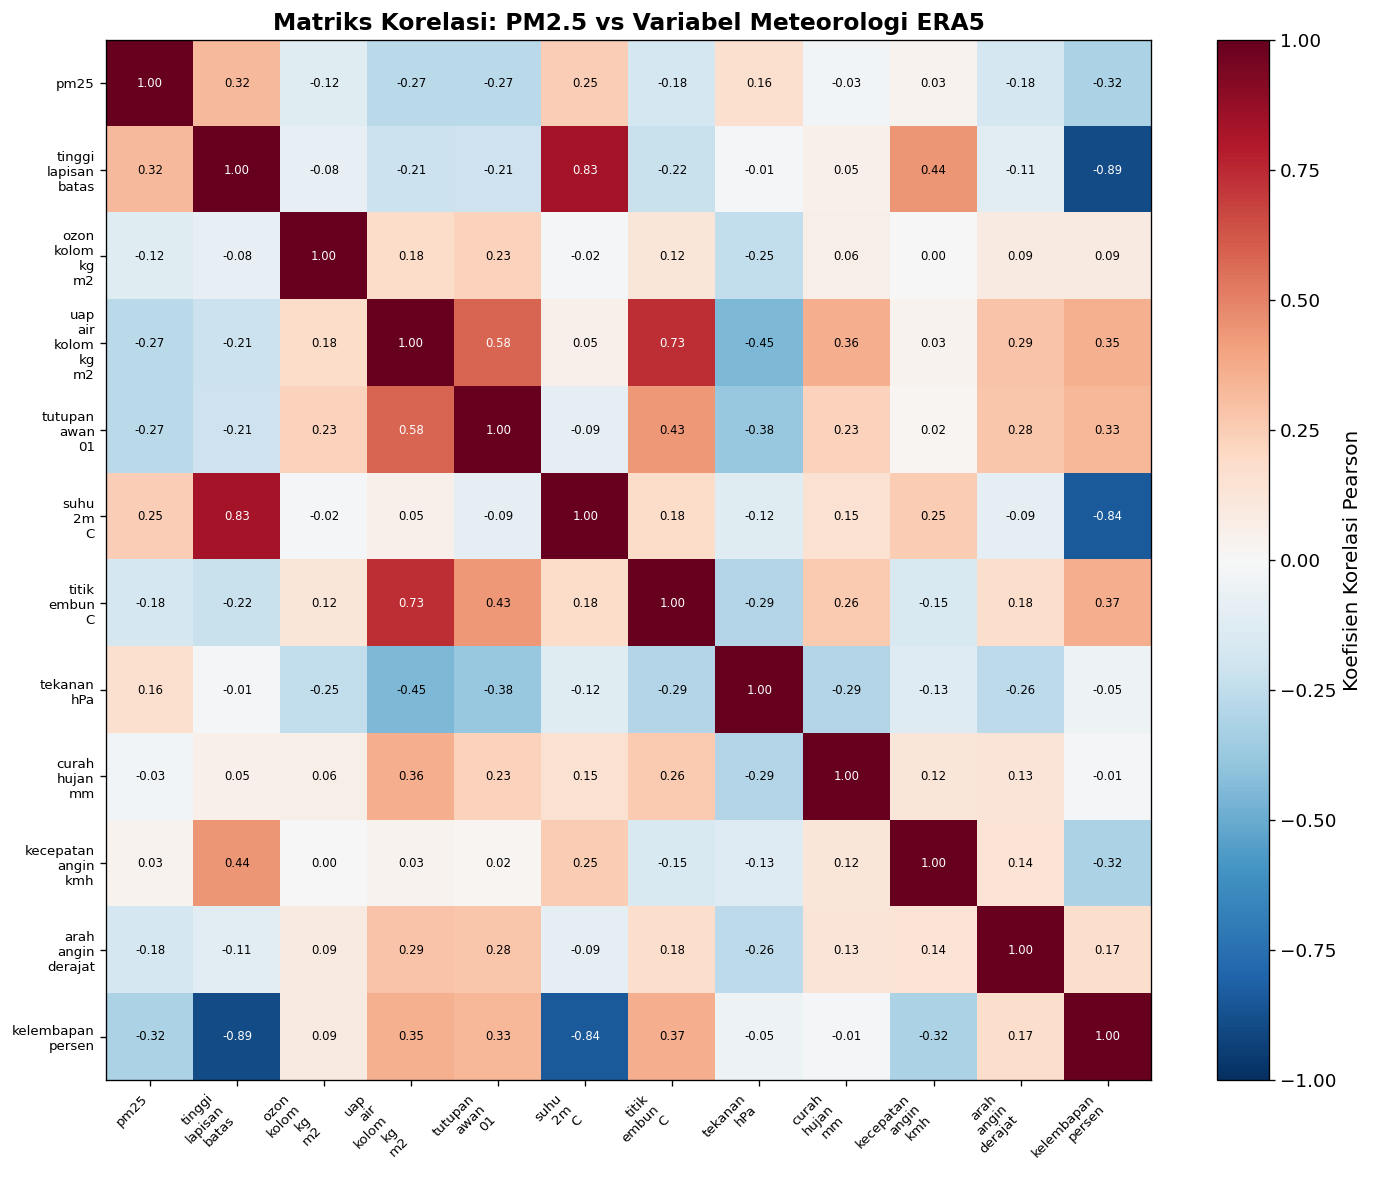

In [ ]:
# Heatmap Korelasi
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = merged.corr()

im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

short_labels = [c.replace('_', '\n')[:20] for c in corr_matrix.columns]
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)

# Anotasi angka korelasi
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Koefisien Korelasi Pearson')
ax.set_title('Matriks Korelasi: PM2.5 vs Variabel Meteorologi ERA5', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '07_korelasi_heatmap.png'))
plt.show()


## 10. Scatter Plot: Top-6 Variabel ERA5 vs PM2.5

Visualisasi hubungan antara 6 variabel ERA5 yang memiliki korelasi terkuat (3 positif + 3 negatif) terhadap PM2.5.


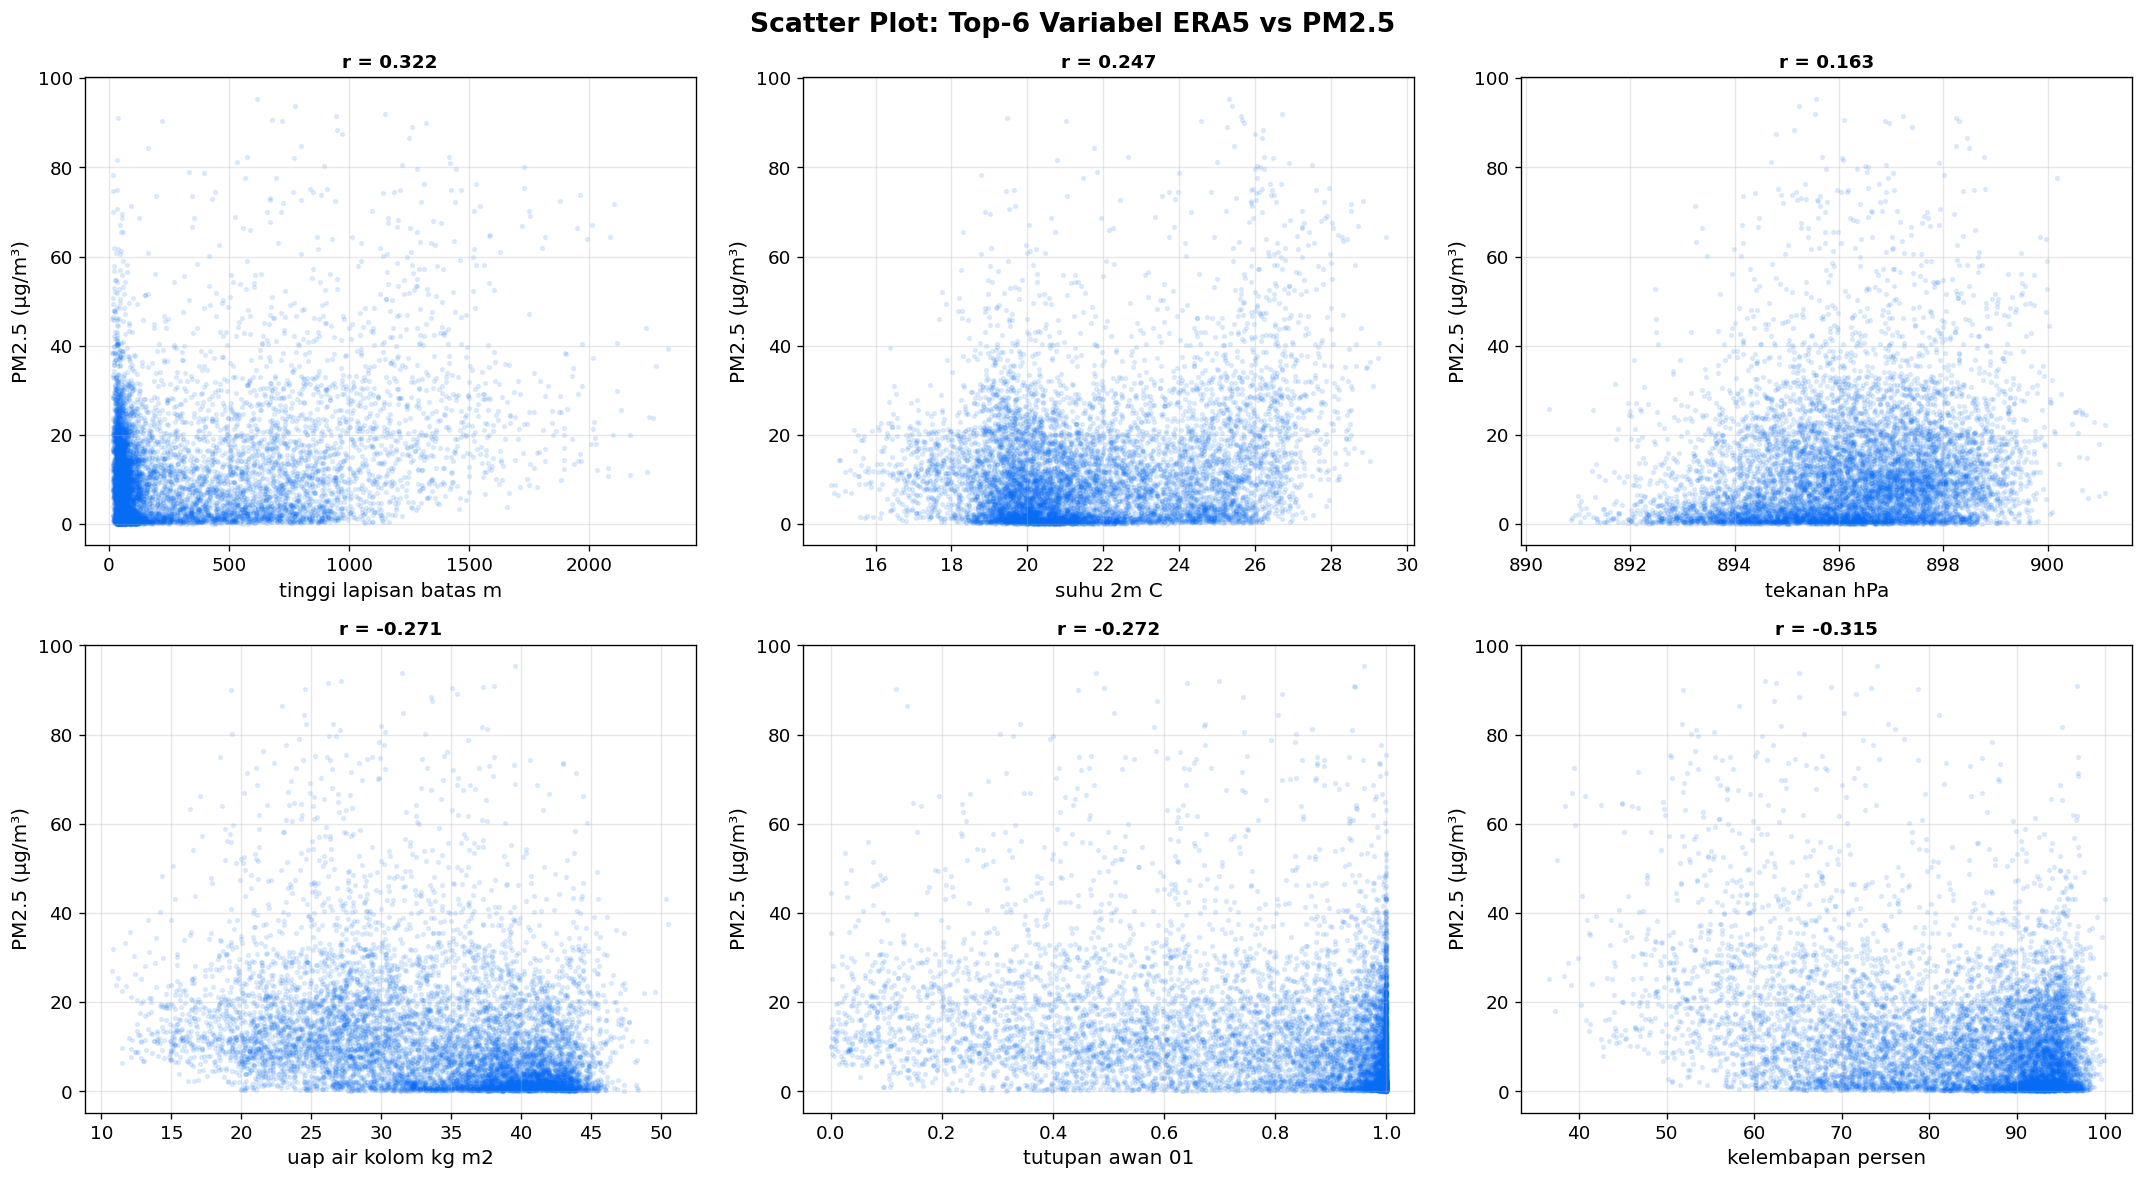

In [ ]:
# Ambil 3 korelasi tertinggi dan 3 terendah
top_vars = corr.head(3).index.tolist() + corr.tail(3).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Scatter Plot: Top-6 Variabel ERA5 vs PM2.5', fontsize=16, fontweight='bold')

for i, var in enumerate(top_vars):
    ax = axes[i // 3, i % 3]
    r = merged[var].corr(merged['pm25'])
    ax.scatter(merged[var], merged['pm25'], alpha=0.1, s=5, color='#066CF4')
    ax.set_xlabel(var.replace('_', ' '))
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'r = {r:.3f}', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Trend line
    z = np.polyfit(merged[var].dropna(), merged.loc[merged[var].dropna().index, 'pm25'], 1)
    p = np.poly1d(z)
    x_range = np.linspace(merged[var].min(), merged[var].max(), 100)
    ax.plot(x_range, p(x_range), color='red', linewidth=2, linestyle='--')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, '08_scatter_top6_era5_vs_pm25.png'))
plt.show()


## 11. Ringkasan & Kesimpulan EDA


In [ ]:
print("=" * 60)
print("📊 RINGKASAN HASIL EDA")
print("=" * 60)

print(f"""
┌─────────────────────────────────────────────────────────┐
│                  DATA ERA5                              │
├─────────────────────────────────────────────────────────┤
│  Total data       : {era5.shape[0]:,} baris (per jam)         │
│  Variabel         : {len(era5.columns)} variabel cuaca               │
│  Periode          : Jan 2022 — Mei 2026                 │
│  Missing values   : 0 (SEMPURNA!)                       │
├─────────────────────────────────────────────────────────┤
│                  DATA SENSOR PM2.5                      │
├─────────────────────────────────────────────────────────┤
│  Sensor utama     : 121867 ({len(sensor_121867):,} points)       │
│  Periode          : Nov 2022 — Mei 2026                 │
├─────────────────────────────────────────────────────────┤
│                  DATA MERGED (OVERLAP)                  │
├─────────────────────────────────────────────────────────┤
│  Total merged     : {len(merged):,} baris                     │
│  Periode          : {str(merged.index.min())[:10]} → {str(merged.index.max())[:10]}       │
├─────────────────────────────────────────────────────────┤
│                  TEMUAN KUNCI                           │
├─────────────────────────────────────────────────────────┤
│  PM2.5 rata-rata  : {pm25_clean['pm25'].mean():.2f} µg/m³ (>WHO 15!)    │
│  PM2.5 kemarau    : {kemarau_mean:.2f} µg/m³                     │
│  PM2.5 hujan      : {hujan_mean:.2f} µg/m³                     │
│  Jam puncak       : {hourly_stats['mean'].idxmax()}:00 WIB                        │
│  Korelasi terkuat : {corr.index[0][:25]:<25s} (r={corr.iloc[0]:+.3f})│
└─────────────────────────────────────────────────────────┘
""")

print("\n🎯 KEPUTUSAN UNTUK FASE PREPROCESSING:")
print("   1. Gunakan HANYA sensor 121867")
print("   2. ERA5 tidak memiliki missing values → siap langsung")
print(f"   3. Data overlap {len(merged):,} baris cukup untuk LSTM")
print("   4. Perlu imputasi untuk missing values di sensor lokal")
print(f"\n📁 Semua plot disimpan di: {OUTPUT_DIR}")


📊 RINGKASAN HASIL EDA

┌─────────────────────────────────────────────────────────┐
│                  DATA ERA5                              │
├─────────────────────────────────────────────────────────┤
│  Total data       : 38,688 baris (per jam)         │
│  Variabel         : 11 variabel cuaca               │
│  Periode          : Jan 2022 — Mei 2026                 │
│  Missing values   : 0 (SEMPURNA!)                       │
├─────────────────────────────────────────────────────────┤
│                  DATA SENSOR PM2.5                      │
├─────────────────────────────────────────────────────────┤
│  Sensor utama     : 121867 (16,541 points)       │
│  Periode          : Nov 2022 — Mei 2026                 │
├─────────────────────────────────────────────────────────┤
│                  DATA MERGED (OVERLAP)                  │
├─────────────────────────────────────────────────────────┤
│  Total merged     : 16,010 baris                     │
│  Periode          : 2022-11-09 → 2

<br><hr><br>
# --- BAGIAN 2: 02_Preprocessing_FeatureEngineering.ipynb ---
<br>

# FASE 2: Preprocessing & Feature Engineering
## Prediksi PM2.5 di Cekungan Bandung Menggunakan LSTM dengan Interpretasi SHAP
**Kerja Praktik — PRSDI BRIN 2026**

---

Notebook ini melanjutkan hasil dari Eksplorasi Data (EDA) dengan fokus menyiapkan data agar siap dimasukkan ke dalam arsitektur *Machine Learning* (Random Forest, XGBoost) dan *Deep Learning* (LSTM, BiLSTM).

**Langkah-langkah utama di notebook ini:**
1. **Handling Missing Values:** Interpolasi nilai `NaN` pada PM2.5 menggunakan metode berbasis waktu.
2. **Feature Engineering:** Ekstraksi fitur waktu siklik (*Cyclical Encoding*), penanda musim, dan variabel Lag historis.
3. **Chronological Train-Validation-Test Split (70/10/20):** Membagi data secara berurutan waktu dengan tiga partisi eksplisit.
4. **Data Normalization:** Penskalaan fitur (MinMaxScaler) yang wajib dilakukan sebelum training model berbasis Neural Network.


## 1. Import Library


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import joblib
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})
print("[OK] Library loaded.")


## 2. Load Dataset Merged (Kontinu)
Kita menggunakan data `merged_pm25_era5v3.csv` yang berisi 1 tahun data berurutan (Nov 2022 - Nov 2023) dengan total 9.480 baris per jam.

> **Justifikasi Penggunaan Data 1 Tahun (Resolusi Per Jam)**
>
> Keputusan untuk menggunakan cakupan data 1 tahun dengan resolusi per jam didasarkan pada dua pertimbangan ilmiah utama:
>
> 1. **Kelengkapan Siklus Musiman:** Satu tahun penuh memastikan model dapat mempelajari kedua pola musim secara seimbang, yaitu musim **kemarau (Juni–September)** dan musim **hujan (Oktober–Mei)**. Penelitian Yin et al. (2021) dan Chen et al. (2024) menegaskan bahwa setidaknya satu siklus musiman tahunan penuh diperlukan agar model mampu menggeneralisasi variasi cuaca yang mempengaruhi konsentrasi polutan.
>
> 2. **Kecukupan Volume Data untuk Deep Learning:** Dengan resolusi per jam, 1 tahun data menghasilkan ±8.760 sampel, melampaui ambang batas *"rule of thumb"* minimum yang direkomendasikan oleh Goodfellow et al. (2016) untuk pelatihan arsitektur LSTM yang stabil, yaitu ≥5.000 sampel per kelas/target. Sebaliknya, resolusi harian (daily) hanya menghasilkan 365 baris — volume yang terbukti tidak cukup untuk konvergensi model *Deep Learning* dan rentan terhadap *overfitting* (Lim & Zohren, 2021).


In [ ]:
# Load data dari Google Drive
data_path = '/content/drive/MyDrive/KP_BRIN/data/raw/merged_pm25_era5v3.csv'
df = pd.read_csv(data_path)

# Rename kolom pertama menjadi datetime dan jadikan index
df.rename(columns={df.columns[0]: 'datetime'}, inplace=True)
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

print(f"Shape Dataset  : {df.shape}")
print(f"Periode        : {df.index.min()} --> {df.index.max()}")
print(f"Total Missing PM2.5 : {df['pm25'].isnull().sum()} baris ({df['pm25'].isnull().mean()*100:.1f}%)")
df.head()


## 3. Handling Missing Values (Imputasi Time-Series)

Karena ini adalah data deret waktu (*time-series*), kita **DILARANG** menggunakan rata-rata global (*mean imputation*). Pengisian dengan rata-rata global akan merusak tren temporal dan memperkenalkan bias statistik yang serius — polutan 'tiba-tiba' kembali ke nilai rata-rata tanpa transisi yang realistis.

Kita menggunakan **Interpolasi Linear Berbasis Waktu** (`method='time'`) untuk menyambung secara mulus antara titik data terakhir sebelum sensor mati dan titik data pertama setelah sensor menyala kembali.

> **Justifikasi:** Metode ini valid karena konsentrasi PM2.5 bersifat kontinu secara fisika — tidak mungkin berubah secara tiba-tiba dari 0 µg/m³ ke 80 µg/m³ tanpa transisi. Metode interpolasi waktu telah menjadi standar dalam studi kualitas udara berbasis sensor *low-cost* (seperti yang diterapkan oleh Zheng et al., 2019 dan Kumar & Sahu, 2021).


In [ ]:
# Visualisasi contoh gap SEBELUM interpolasi (April-Mei 2023)
subset_gaps = df.loc['2023-04-10':'2023-05-10'].copy()

plt.figure(figsize=(15, 4))
plt.plot(subset_gaps.index, subset_gaps['pm25'], color='red',
         marker='.', linestyle='-', markersize=3, label='PM2.5 Asli (Ada Gap)')
plt.title("Kondisi Sebelum Interpolasi (April-Mei 2023) — Terlihat Gap (Data Hilang)")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Waktu")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Lakukan interpolasi linear berbasis waktu
df['pm25'] = df['pm25'].interpolate(method='time')

# Verifikasi
print(f"Total Missing setelah interpolasi: {df['pm25'].isnull().sum()} baris")

# Visualisasi SETELAH interpolasi
subset_fixed = df.loc['2023-04-10':'2023-05-10'].copy()
plt.figure(figsize=(15, 4))
plt.plot(subset_fixed.index, subset_fixed['pm25'], color='green',
         marker='.', linestyle='-', markersize=3, label='PM2.5 Setelah Interpolasi')
plt.title("Kondisi Setelah Interpolasi (April-Mei 2023) — Gap Terisi Mulus")
plt.ylabel("PM2.5 (µg/m³)")
plt.xlabel("Waktu")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Feature Engineering

Menambahkan variabel/kolom baru yang akan sangat membantu model mempelajari pola musiman dan temporal dari data.

### 4.1 Ekstraksi Fitur Waktu (Temporal Features)


In [ ]:
# Ambil info jam, hari, dan bulan
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month

# Fitur Musim Biner (1=Kemarau, 0=Hujan)
# Kemarau di Bandung: Juni (6) - September (9)
df['is_dry_season'] = df['month'].apply(lambda x: 1 if x in [6, 7, 8, 9] else 0)

print("Fitur temporal berhasil ditambahkan:")
df[['hour', 'day_of_week', 'month', 'is_dry_season']].head()


### 4.2 Encoding Siklik (*Cyclical Encoding*)

Jam 23:00 dan jam 00:00 sebenarnya hanya berjarak 1 jam, tetapi secara numerik selisihnya 23. Hal yang sama berlaku untuk bulan: Desember (12) dan Januari (1) sebenarnya berdekatan, tetapi secara numerik selisihnya 11.

Jika kita membiarkan representasi numerik linear ini, algoritma akan salah menginterpretasikan jarak temporal. Oleh karena itu, fitur waktu harus dikodekan ke dalam bentuk gelombang **Sinus** dan **Cosinus** sehingga hubungan sikliknya terjaga:

$$\text{hour\_sin} = \sin\left(\frac{\text{jam} \times 2\pi}{24}\right), \quad \text{hour\_cos} = \cos\left(\frac{\text{jam} \times 2\pi}{24}\right)$$


In [ ]:
# Transformasi Siklik untuk Jam (Siklus 24 Jam)
df['hour_sin'] = np.sin(df['hour'] * (2. * np.pi / 24))
df['hour_cos'] = np.cos(df['hour'] * (2. * np.pi / 24))

# Transformasi Siklik untuk Bulan (Siklus 12 Bulan)
df['month_sin'] = np.sin((df['month'] - 1) * (2. * np.pi / 12))
df['month_cos'] = np.cos((df['month'] - 1) * (2. * np.pi / 12))

# Hapus kolom integer asli (tidak diperlukan lagi)
df.drop(columns=['hour', 'month'], inplace=True)

print("Encoding siklik selesai. Kolom baru: hour_sin, hour_cos, month_sin, month_cos")


### 4.3 Fitur Historis (*Lagged Features*)

Konsentrasi PM2.5 di atmosfer bersifat kumulatif: nilai saat ini sangat bergantung pada nilai jam-jam sebelumnya karena partikel tidak langsung hilang dari udara. Dua variabel lag yang paling penting ditambahkan:

- **`pm25_lag_1h`** → Nilai PM2.5 satu jam sebelumnya ($T-1$): Menangkap autokorelasi jangka pendek
- **`pm25_lag_24h`** → Nilai PM2.5 24 jam sebelumnya ($T-24$): Menangkap pola diurnal yang berulang setiap hari di jam yang sama


In [ ]:
# Lag 1 Jam (T-1)
df['pm25_lag_1h'] = df['pm25'].shift(1)

# Lag 24 Jam (T-24, pola diurnal)
df['pm25_lag_24h'] = df['pm25'].shift(24)

# Hapus 24 baris pertama yang menghasilkan NaN akibat shift
df.dropna(inplace=True)

print(f"Shape data setelah Feature Engineering: {df.shape}")
print(f"\nDaftar semua fitur ({len(df.columns)} kolom):")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2d}. {col}")


## 5. Train - Validation - Test Split (70% / 10% / 20%)

Dalam pemodelan *Time-Series*, kita **DILARANG** membagi data secara acak (`train_test_split(shuffle=True)`). Pembagian acak menyebabkan **kebocoran data (*data leakage*)** — model secara tidak sengaja 'melihat' masa depan selama pelatihan, yang membuat evaluasi akurasi menjadi tidak valid.

Kita menggunakan pembagian **kronologis** (berurutan waktu) menjadi **tiga partisi eksplisit**:

| Partisi | Proporsi | Fungsi |
|---|---|---|
| **Training** | 70% | Melatih semua model (RF, XGBoost, LSTM, BiLSTM) |
| **Validation** | 10% | Tuning hyperparameter & Early Stopping LSTM |
| **Testing** | 20% | Evaluasi akurasi akhir yang murni dan adil |

> **Justifikasi Rasio 70/10/20:**
>
> Rasio ini merupakan standar yang banyak digunakan dalam penelitian prediksi *time-series* berbasis *Deep Learning* (Lim & Zohren, 2021; Yin et al., 2021). Alasan spesifik untuk setiap partisi:
>
> - **70% Training:** Memastikan model mendapatkan cukup data untuk mempelajari kedua siklus musiman (kemarau dan hujan). Dengan ~6.132 jam data latih, volume ini memenuhi kebutuhan minimum LSTM yang stabil.
> - **10% Validation (~876 jam ≈ 1 bulan):** Cukup representatif untuk mengevaluasi konvergensi model *epoch* per *epoch* (Early Stopping) dan juga sebagai dasar tuning hyperparameter Random Forest dan XGBoost secara adil.
> - **20% Testing (~1.752 jam ≈ 2,5 bulan):** Mengikuti prinsip bahwa data test harus cukup besar untuk mencakup variasi kondisi cuaca yang bermakna, sehingga evaluasi RMSE, MAE, dan R² dapat dianggap representatif secara statistik (Hyndman & Athanasopoulos, 2021).


In [ ]:
total = len(df)

# Hitung indeks batas
train_end = int(total * 0.70)
val_end   = int(total * 0.80)  # 70% + 10% = 80%

# Bagi secara kronologis
train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("=" * 65)
print(f"{'Partisi':<12} {'Baris':>8}  {'Dari':<22} {'Sampai':<22}")
print("=" * 65)
print(f"{'Training':<12} {len(train_df):>8,}  {str(train_df.index.min())[:19]:<22} {str(train_df.index.max())[:19]:<22}")
print(f"{'Validation':<12} {len(val_df):>8,}  {str(val_df.index.min())[:19]:<22} {str(val_df.index.max())[:19]:<22}")
print(f"{'Testing':<12} {len(test_df):>8,}  {str(test_df.index.min())[:19]:<22} {str(test_df.index.max())[:19]:<22}")
print("=" * 65)
print(f"Total baris  : {len(df):,}")
print(f"Rasio aktual : Train={len(train_df)/total*100:.1f}% / Val={len(val_df)/total*100:.1f}% / Test={len(test_df)/total*100:.1f}%")


In [ ]:
# Visualisasi pembagian data
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train_df.index, train_df['pm25'], color='royalblue', linewidth=0.6,
        label=f'Training ({len(train_df):,} jam | 70%)')
ax.plot(val_df.index, val_df['pm25'], color='darkorange', linewidth=0.6,
        label=f'Validation ({len(val_df):,} jam | 10%)')
ax.plot(test_df.index, test_df['pm25'], color='forestgreen', linewidth=0.6,
        label=f'Testing ({len(test_df):,} jam | 20%)')

ax.axvline(x=train_df.index[-1], color='royalblue', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(x=val_df.index[-1], color='darkorange', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title('Chronological Train/Validation/Test Split (70% / 10% / 20%)', fontsize=13, fontweight='bold')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.set_xlabel('Waktu')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Normalisasi (*Min-Max Scaling*)

Jaringan Saraf Tiruan (*Deep Learning* / LSTM) sangat sensitif terhadap perbedaan skala antar variabel. Misalnya, variabel `tekanan_hPa` memiliki rentang 890–901, sementara `tutupan_awan_01` hanya 0–1. Perbedaan skala ini menyebabkan model terdominasi oleh variabel berskala besar dan gradien menjadi tidak stabil (*exploding/vanishing gradient*).

Semua fitur ditekan ke rentang **[0, 1]** menggunakan `MinMaxScaler`.

> **Aturan Krusial (Anti Data Leakage):** Scaler di-*fit* **hanya menggunakan data Training**, lalu di-*transform* ke Validation dan Testing. Hal ini memastikan statistik minimum/maksimum dari data masa depan tidak bocor ke proses normalisasi data latih.


In [ ]:
target_col = 'pm25'
feature_cols = [c for c in df.columns if c != target_col]

# Inisialisasi dua scaler terpisah
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# === FIT hanya pada Training ===
X_train_s = scaler_X.fit_transform(train_df[feature_cols])
y_train_s = scaler_y.fit_transform(train_df[[target_col]])

# === HANYA TRANSFORM (tanpa fit) pada Validation ===
X_val_s = scaler_X.transform(val_df[feature_cols])
y_val_s = scaler_y.transform(val_df[[target_col]])

# === HANYA TRANSFORM (tanpa fit) pada Testing ===
X_test_s = scaler_X.transform(test_df[feature_cols])
y_test_s = scaler_y.transform(test_df[[target_col]])

# Kembalikan ke DataFrame agar rapi
train_scaled = pd.DataFrame(X_train_s, columns=feature_cols, index=train_df.index)
train_scaled[target_col] = y_train_s

val_scaled = pd.DataFrame(X_val_s, columns=feature_cols, index=val_df.index)
val_scaled[target_col] = y_val_s

test_scaled = pd.DataFrame(X_test_s, columns=feature_cols, index=test_df.index)
test_scaled[target_col] = y_test_s

print("Contoh data Training setelah di-scaling (semua rentang 0 sampai 1):")
print(train_scaled.describe().round(3))


## 7. Simpan Data Siap Model

Data yang sudah bersih, direkayasa, dan diskalakan disimpan untuk digunakan oleh Notebook pemodelan (Notebook 03, 04, dan 05).


In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/KP_BRIN/data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Simpan tiga partisi data
train_scaled.to_csv(os.path.join(OUTPUT_DIR, 'train_scaled.csv'))
val_scaled.to_csv(os.path.join(OUTPUT_DIR, 'val_scaled.csv'))
test_scaled.to_csv(os.path.join(OUTPUT_DIR, 'test_scaled.csv'))

# Simpan Scaler (penting untuk membalikkan prediksi ke satuan ug/m3 asli)
joblib.dump(scaler_X, os.path.join(OUTPUT_DIR, 'scaler_X.pkl'))
joblib.dump(scaler_y, os.path.join(OUTPUT_DIR, 'scaler_y.pkl'))

print(f"[OK] Seluruh data dan Scaler berhasil disimpan di:")
print(f"     {OUTPUT_DIR}")
print(f"")
print(f"File yang disimpan:")
print(f"  -> train_scaled.csv  ({len(train_scaled):,} baris)")
print(f"  -> val_scaled.csv    ({len(val_scaled):,} baris)")
print(f"  -> test_scaled.csv   ({len(test_scaled):,} baris)")
print(f"  -> scaler_X.pkl")
print(f"  -> scaler_y.pkl")


<br><hr><br>
# --- BAGIAN 3: 03_Baseline_Models.ipynb ---
<br>

# FASE 3: Pemodelan Baseline (Random Forest & XGBoost) + Hyperparameter Tuning
## Prediksi PM2.5 di Cekungan Bandung
**Kerja Praktik — PRSDI BRIN 2026**

---

Notebook ini melatih model *Machine Learning* klasik berbasis *Ensemble Trees*, yaitu **Random Forest** dan **XGBoost**, sebagai model baseline (tolok ukur). Kedua model ini dioptimasi menggunakan **Hyperparameter Tuning** agar perbandingan dengan LSTM/BiLSTM bersifat adil (*fair comparison*).

**Alur Notebook:**
1. Load data Train, Validation, dan Test yang sudah diproses.
2. Melatih Random Forest dengan parameter default sebagai *baseline awal*.
3. Melakukan **Hyperparameter Tuning** menggunakan data Validasi.
4. Mengevaluasi model terbaik pada data Testing.
5. Menyimpan model yang sudah dioptimasi.


## 1. Import Library


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import time

# Evaluasi
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})
print("[OK] Library loaded.")


## 2. Load Data Processed & Scaler

Memuat tiga partisi data (Train/Validation/Test) yang sudah bersih dan terskala dari hasil Notebook 02.


In [ ]:
DATA_DIR = '/content/drive/MyDrive/KP_BRIN/data/processed'

# Load Dataset (3 partisi)
train_scaled = pd.read_csv(os.path.join(DATA_DIR, 'train_scaled.csv'), index_col=0, parse_dates=True)
val_scaled   = pd.read_csv(os.path.join(DATA_DIR, 'val_scaled.csv'), index_col=0, parse_dates=True)
test_scaled  = pd.read_csv(os.path.join(DATA_DIR, 'test_scaled.csv'), index_col=0, parse_dates=True)

# Load Scaler Target (Y) untuk inversi nanti
scaler_y = joblib.load(os.path.join(DATA_DIR, 'scaler_y.pkl'))

# Pisahkan Fitur (X) dan Target (y)
target_col = 'pm25'

X_train = train_scaled.drop(columns=[target_col])
y_train = train_scaled[target_col]

X_val = val_scaled.drop(columns=[target_col])
y_val = val_scaled[target_col]

X_test = test_scaled.drop(columns=[target_col])
y_test = test_scaled[target_col]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")


## 3. Fungsi Evaluasi (Inversi ke Satuan Asli)

Semua model memprediksi dalam skala [0, 1]. Agar metrik akurasi bermakna secara fisik, kita harus mengubah prediksi kembali ke satuan $\mu g/m^3$ menggunakan `inverse_transform` sebelum menghitung RMSE, MAE, dan R².


In [ ]:
def evaluate_model(model_name, y_true_scaled, y_pred_scaled, verbose=True):
    """Mengevaluasi model dengan menginversi skala kembali ke ug/m3."""
    y_true_inv = scaler_y.inverse_transform(y_true_scaled.values.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    r2   = r2_score(y_true_inv, y_pred_inv)

    if verbose:
        print(f"=== Kinerja Model: {model_name} ===")
        print(f"  RMSE : {rmse:.4f} ug/m3")
        print(f"  MAE  : {mae:.4f} ug/m3")
        print(f"  R2   : {r2:.4f}")

    return {'name': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2,
            'y_true': y_true_inv, 'y_pred': y_pred_inv}


## 4. Random Forest: Default + Hyperparameter Tuning

### 4.1 Baseline (Parameter Default)
Langkah pertama: melatih Random Forest dengan konfigurasi standar untuk mendapatkan *baseline awal*.


In [ ]:
print("--- Random Forest: Parameter Default ---")
rf_default = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

start = time.time()
rf_default.fit(X_train, y_train)
print(f"Training selesai ({time.time()-start:.1f} detik)")

# Evaluasi pada Validation Set
y_pred_rf_val = rf_default.predict(X_val)
rf_default_val_result = evaluate_model("RF Default (Validasi)", y_val, y_pred_rf_val)

# Evaluasi pada Test Set
y_pred_rf_test = rf_default.predict(X_test)
rf_default_test_result = evaluate_model("RF Default (Testing)", y_test, y_pred_rf_test)


### 4.2 Hyperparameter Tuning Random Forest

Kita mencoba beberapa kombinasi hyperparameter dan memilih yang memberikan **RMSE terendah pada data Validasi**. Tuning dilakukan secara manual (*Grid Search*) pada parameter berikut:

- `n_estimators`: Jumlah pohon keputusan [100, 200, 300]
- `max_depth`: Kedalaman maksimum pohon [10, 20, None]
- `min_samples_split`: Jumlah sampel minimum untuk membelah node [2, 5, 10]


In [ ]:
print("--- Hyperparameter Tuning Random Forest ---")
print("Mengevaluasi kombinasi parameter pada data Validasi...\n")

rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

best_rf_rmse = float('inf')
best_rf_params = None
best_rf_model = None
rf_results = []

total_combos = (len(rf_param_grid['n_estimators']) *
                len(rf_param_grid['max_depth']) *
                len(rf_param_grid['min_samples_split']))
combo_idx = 0

for n_est in rf_param_grid['n_estimators']:
    for max_d in rf_param_grid['max_depth']:
        for min_split in rf_param_grid['min_samples_split']:
            combo_idx += 1
            model = RandomForestRegressor(
                n_estimators=n_est, max_depth=max_d,
                min_samples_split=min_split,
                random_state=42, n_jobs=-1
            )
            model.fit(X_train, y_train)
            y_pred_val = model.predict(X_val)
            res = evaluate_model(f"RF [{combo_idx}/{total_combos}]", y_val, y_pred_val, verbose=False)

            rf_results.append({
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'val_rmse': res['rmse'],
                'val_mae': res['mae'],
                'val_r2': res['r2']
            })

            if res['rmse'] < best_rf_rmse:
                best_rf_rmse = res['rmse']
                best_rf_params = {'n_estimators': n_est, 'max_depth': max_d, 'min_samples_split': min_split}
                best_rf_model = model

            print(f"  [{combo_idx:2d}/{total_combos}] n_est={n_est:3d} | max_d={str(max_d):>5s} | min_split={min_split:2d} --> Val RMSE={res['rmse']:.4f}")

print(f"\n>> Best RF Params: {best_rf_params}")
print(f">> Best RF Val RMSE: {best_rf_rmse:.4f}")


In [ ]:
# Evaluasi model RF terbaik pada Test Set
print("--- Evaluasi RF Terbaik pada Data Testing ---")
y_pred_rf_best_test = best_rf_model.predict(X_test)
rf_tuned_test_result = evaluate_model("RF Tuned (Testing)", y_test, y_pred_rf_best_test)

print(f"\nPerbandingan RF Default vs RF Tuned (pada Test Set):")
print(f"  Default --> RMSE: {rf_default_test_result['rmse']:.4f} | MAE: {rf_default_test_result['mae']:.4f} | R2: {rf_default_test_result['r2']:.4f}")
print(f"  Tuned   --> RMSE: {rf_tuned_test_result['rmse']:.4f} | MAE: {rf_tuned_test_result['mae']:.4f} | R2: {rf_tuned_test_result['r2']:.4f}")


## 5. XGBoost: Default + Hyperparameter Tuning

### 5.1 Baseline (Parameter Default)


In [ ]:
print("--- XGBoost: Parameter Default ---")
xgb_default = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1,
    max_depth=6, random_state=42, n_jobs=-1
)

start = time.time()
xgb_default.fit(X_train, y_train)
print(f"Training selesai ({time.time()-start:.1f} detik)")

# Evaluasi Validation
y_pred_xgb_val = xgb_default.predict(X_val)
xgb_default_val_result = evaluate_model("XGB Default (Validasi)", y_val, y_pred_xgb_val)

# Evaluasi Testing
y_pred_xgb_test = xgb_default.predict(X_test)
xgb_default_test_result = evaluate_model("XGB Default (Testing)", y_test, y_pred_xgb_test)


### 5.2 Hyperparameter Tuning XGBoost

Parameter yang dioptimasi:
- `n_estimators`: Jumlah iterasi boosting [100, 200, 300]
- `learning_rate`: Kecepatan pembelajaran [0.01, 0.05, 0.1]
- `max_depth`: Kedalaman pohon [4, 6, 8]


In [ ]:
print("--- Hyperparameter Tuning XGBoost ---")
print("Mengevaluasi kombinasi parameter pada data Validasi...\n")

xgb_param_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [4, 6, 8]
}

best_xgb_rmse = float('inf')
best_xgb_params = None
best_xgb_model = None
xgb_results = []

total_combos = (len(xgb_param_grid['n_estimators']) *
                len(xgb_param_grid['learning_rate']) *
                len(xgb_param_grid['max_depth']))
combo_idx = 0

for n_est in xgb_param_grid['n_estimators']:
    for lr in xgb_param_grid['learning_rate']:
        for max_d in xgb_param_grid['max_depth']:
            combo_idx += 1
            model = xgb.XGBRegressor(
                n_estimators=n_est, learning_rate=lr,
                max_depth=max_d, random_state=42, n_jobs=-1
            )
            model.fit(X_train, y_train)
            y_pred_val = model.predict(X_val)
            res = evaluate_model(f"XGB [{combo_idx}/{total_combos}]", y_val, y_pred_val, verbose=False)

            xgb_results.append({
                'n_estimators': n_est,
                'learning_rate': lr,
                'max_depth': max_d,
                'val_rmse': res['rmse'],
                'val_mae': res['mae'],
                'val_r2': res['r2']
            })

            if res['rmse'] < best_xgb_rmse:
                best_xgb_rmse = res['rmse']
                best_xgb_params = {'n_estimators': n_est, 'learning_rate': lr, 'max_depth': max_d}
                best_xgb_model = model

            print(f"  [{combo_idx:2d}/{total_combos}] n_est={n_est:3d} | lr={lr:.2f} | max_d={max_d} --> Val RMSE={res['rmse']:.4f}")

print(f"\n>> Best XGB Params: {best_xgb_params}")
print(f">> Best XGB Val RMSE: {best_xgb_rmse:.4f}")


In [ ]:
# Evaluasi model XGBoost terbaik pada Test Set
print("--- Evaluasi XGBoost Terbaik pada Data Testing ---")
y_pred_xgb_best_test = best_xgb_model.predict(X_test)
xgb_tuned_test_result = evaluate_model("XGB Tuned (Testing)", y_test, y_pred_xgb_best_test)

print(f"\nPerbandingan XGB Default vs XGB Tuned (pada Test Set):")
print(f"  Default --> RMSE: {xgb_default_test_result['rmse']:.4f} | MAE: {xgb_default_test_result['mae']:.4f} | R2: {xgb_default_test_result['r2']:.4f}")
print(f"  Tuned   --> RMSE: {xgb_tuned_test_result['rmse']:.4f} | MAE: {xgb_tuned_test_result['mae']:.4f} | R2: {xgb_tuned_test_result['r2']:.4f}")


## 6. Ringkasan Perbandingan Baseline


In [ ]:
# Tabel ringkasan semua model baseline
summary_data = [
    ['RF Default',  rf_default_test_result['rmse'],  rf_default_test_result['mae'],  rf_default_test_result['r2']],
    ['RF Tuned',    rf_tuned_test_result['rmse'],    rf_tuned_test_result['mae'],    rf_tuned_test_result['r2']],
    ['XGB Default', xgb_default_test_result['rmse'], xgb_default_test_result['mae'], xgb_default_test_result['r2']],
    ['XGB Tuned',   xgb_tuned_test_result['rmse'],   xgb_tuned_test_result['mae'],   xgb_tuned_test_result['r2']],
]

summary_df = pd.DataFrame(summary_data, columns=['Model', 'RMSE (ug/m3)', 'MAE (ug/m3)', 'R2'])
summary_df = summary_df.sort_values('RMSE (ug/m3)')

print("=" * 65)
print("RINGKASAN PERBANDINGAN MODEL BASELINE (Evaluasi pada Test Set)")
print("=" * 65)
print(summary_df.to_string(index=False))
print("=" * 65)
print(f"\nTarget LSTM/BiLSTM: Mengalahkan RMSE terbaik baseline di atas.")


## 7. Visualisasi Perbandingan (Time-Series)

Membandingkan prediksi model baseline terbaik (RF Tuned dan XGB Tuned) terhadap nilai aktual pada 2 minggu pertama data Test.


In [ ]:
# Ambil 14 hari pertama (14 * 24 jam = 336 baris)
subset_len = min(336, len(y_test))

time_axis = y_test.index[:subset_len]
actual    = rf_tuned_test_result['y_true'][:subset_len]
rf_pred   = rf_tuned_test_result['y_pred'][:subset_len]
xgb_pred  = xgb_tuned_test_result['y_pred'][:subset_len]

plt.figure(figsize=(16, 6))
plt.plot(time_axis, actual,   label='Aktual (PM2.5)', color='black', linewidth=2)
plt.plot(time_axis, rf_pred,  label='RF Tuned', color='blue', alpha=0.7, linestyle='--')
plt.plot(time_axis, xgb_pred, label='XGB Tuned', color='red', alpha=0.7, linestyle='-.')

plt.title("Prediksi Baseline vs Aktual (2 Minggu Pertama Data Test)", fontweight='bold')
plt.ylabel("PM2.5 (ug/m3)")
plt.xlabel("Waktu")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Menyimpan Model Terbaik

Model yang telah dioptimasi disimpan untuk digunakan ulang pada Fase 5 (SHAP Interpretation).


In [ ]:
MODEL_DIR = '/content/drive/MyDrive/KP_BRIN/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan Random Forest terbaik
joblib.dump(best_rf_model, os.path.join(MODEL_DIR, 'rf_tuned.pkl'))

# Simpan XGBoost terbaik
best_xgb_model.save_model(os.path.join(MODEL_DIR, 'xgb_tuned.json'))

# Simpan juga ringkasan hasil tuning
pd.DataFrame(rf_results).to_csv(os.path.join(MODEL_DIR, 'rf_tuning_results.csv'), index=False)
pd.DataFrame(xgb_results).to_csv(os.path.join(MODEL_DIR, 'xgb_tuning_results.csv'), index=False)

print(f"[OK] Model dan hasil tuning berhasil disimpan di: {MODEL_DIR}")
print(f"  -> rf_tuned.pkl             (Best RF: {best_rf_params})")
print(f"  -> xgb_tuned.json           (Best XGB: {best_xgb_params})")
print(f"  -> rf_tuning_results.csv    (Log semua kombinasi RF)")
print(f"  -> xgb_tuning_results.csv   (Log semua kombinasi XGB)")


<br><hr><br>
# --- BAGIAN 4: 04_LSTM_Model.ipynb ---
<br>

# FASE 4: Pemodelan Deep Learning (LSTM & BiLSTM)
## Prediksi PM2.5 di Cekungan Bandung
**Kerja Praktik — PRSDI BRIN 2026**

---

Notebook ini melatih dua arsitektur Deep Learning berbasis *Recurrent Neural Network*:
1. **Stacked LSTM** — membaca urutan waktu dari satu arah (maju)
2. **BiLSTM (Bidirectional LSTM)** — membaca urutan waktu dari dua arah (maju dan mundur)

Kedua model menggunakan **data Validasi eksplisit** untuk *Early Stopping* dan pemilihan arsitektur terbaik.

**Target:** Mengalahkan skor RMSE baseline terbaik (RF Tuned / XGB Tuned) dari Notebook 03.


## 1. Import Library


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import time

# Evaluasi
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})
print("[OK] Library loaded.")


## 2. Load Data Processed & Scaler


In [ ]:
DATA_DIR = '/content/drive/MyDrive/KP_BRIN/data/processed'

train_scaled = pd.read_csv(os.path.join(DATA_DIR, 'train_scaled.csv'), index_col=0, parse_dates=True)
val_scaled   = pd.read_csv(os.path.join(DATA_DIR, 'val_scaled.csv'), index_col=0, parse_dates=True)
test_scaled  = pd.read_csv(os.path.join(DATA_DIR, 'test_scaled.csv'), index_col=0, parse_dates=True)

scaler_y = joblib.load(os.path.join(DATA_DIR, 'scaler_y.pkl'))

target_col = 'pm25'
print(f"Train : {train_scaled.shape}")
print(f"Val   : {val_scaled.shape}")
print(f"Test  : {test_scaled.shape}")


## 3. Transformasi Data: Tabel 2D menjadi Tensor 3D (*Sliding Window*)

LSTM membutuhkan input berbentuk **Tensor 3D**: `[Jumlah Sampel, Jendela Waktu, Jumlah Fitur]`.

Parameter `TIME_STEPS = 24` berarti untuk memprediksi PM2.5 di jam ke-25, model diberi konteks cuaca dan polusi selama **24 jam sebelumnya** (1 hari penuh).


In [ ]:
def create_sequences(df, target_col, time_steps=24):
    """Mengubah DataFrame 2D menjadi Tensor 3D untuk LSTM."""
    X, y = [], []
    data_array = df.values
    target_idx = df.columns.get_loc(target_col)

    for i in range(len(data_array) - time_steps):
        X.append(data_array[i:(i + time_steps)])
        y.append(data_array[i + time_steps, target_idx])

    return np.array(X), np.array(y)

TIME_STEPS = 24

X_train_seq, y_train_seq = create_sequences(train_scaled, target_col, TIME_STEPS)
X_val_seq,   y_val_seq   = create_sequences(val_scaled, target_col, TIME_STEPS)
X_test_seq,  y_test_seq  = create_sequences(test_scaled, target_col, TIME_STEPS)

n_features = X_train_seq.shape[2]

print(f"Tensor X_train : {X_train_seq.shape} --> [Sampel, TimeSteps, Fitur]")
print(f"Tensor X_val   : {X_val_seq.shape}")
print(f"Tensor X_test  : {X_test_seq.shape}")
print(f"Jumlah fitur   : {n_features}")


## 4. Model 1: Stacked LSTM

### Arsitektur:
```
Input         : (24, n_fitur)
LSTM Layer 1  : 64 unit, return_sequences=True
Dropout       : 0.2
LSTM Layer 2  : 32 unit, return_sequences=False
Dropout       : 0.2
Dense Output  : 1 unit
```

Data **Validasi eksplisit** digunakan untuk `EarlyStopping` (bukan `validation_split` dari data Training).


In [ ]:
def build_lstm(n_timesteps, n_features):
    """Membangun arsitektur Stacked LSTM."""
    model = Sequential()
    model.add(Input(shape=(n_timesteps, n_features)))
    model.add(LSTM(units=64, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(units=32, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

lstm_model = build_lstm(TIME_STEPS, n_features)
lstm_model.summary()


In [ ]:
print("Melatih Stacked LSTM...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

start = time.time()
lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),  # Validasi eksplisit
    callbacks=[early_stop],
    verbose=1
)
lstm_train_time = time.time() - start
print(f"\nTraining LSTM selesai ({lstm_train_time:.1f} detik)")


## 5. Model 2: BiLSTM (Bidirectional LSTM)

BiLSTM membaca urutan waktu dari **dua arah sekaligus** (maju dan mundur). Dalam konteks prediksi PM2.5, ini memungkinkan model untuk menangkap hubungan temporal yang lebih kaya — misalnya, kondisi cuaca 24 jam ke belakang mungkin memiliki pola yang saling bergantung di kedua ujung jendela waktu.

### Arsitektur:
```
Input              : (24, n_fitur)
Bidirectional LSTM : 64 unit (128 total output), return_sequences=True
Dropout            : 0.2
Bidirectional LSTM : 32 unit (64 total output), return_sequences=False
Dropout            : 0.2
Dense Output       : 1 unit
```


In [ ]:
def build_bilstm(n_timesteps, n_features):
    """Membangun arsitektur Bidirectional LSTM."""
    model = Sequential()
    model.add(Input(shape=(n_timesteps, n_features)))
    model.add(Bidirectional(LSTM(units=64, return_sequences=True)))
    model.add(Dropout(0.2))
    model.add(Bidirectional(LSTM(units=32, return_sequences=False)))
    model.add(Dropout(0.2))
    model.add(Dense(units=1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

bilstm_model = build_bilstm(TIME_STEPS, n_features)
bilstm_model.summary()


In [ ]:
print("Melatih Bidirectional LSTM...")

early_stop_bi = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

start = time.time()
bilstm_history = bilstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop_bi],
    verbose=1
)
bilstm_train_time = time.time() - start
print(f"\nTraining BiLSTM selesai ({bilstm_train_time:.1f} detik)")


## 6. Kurva Pembelajaran (*Learning Curves*)

Membandingkan proses belajar LSTM vs BiLSTM. Idealnya, *training loss* dan *validation loss* harus turun bersamaan tanpa divergensi besar (tanda *overfitting*).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LSTM
axes[0].plot(lstm_history.history['loss'], label='Train Loss', color='royalblue')
axes[0].plot(lstm_history.history['val_loss'], label='Val Loss', color='darkorange')
axes[0].set_title('Stacked LSTM - Learning Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# BiLSTM
axes[1].plot(bilstm_history.history['loss'], label='Train Loss', color='royalblue')
axes[1].plot(bilstm_history.history['val_loss'], label='Val Loss', color='darkorange')
axes[1].set_title('BiLSTM - Learning Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Evaluasi Akhir pada Data Testing


In [ ]:
def evaluate_dl_model(model_name, model, X_seq, y_seq):
    """Mengevaluasi model DL: prediksi, inversi, hitung metrik."""
    y_pred_s = model.predict(X_seq, verbose=0)
    y_true_inv = scaler_y.inverse_transform(y_seq.reshape(-1, 1)).flatten()
    y_pred_inv = scaler_y.inverse_transform(y_pred_s).flatten()

    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    r2   = r2_score(y_true_inv, y_pred_inv)

    print(f"=== Kinerja Model: {model_name} ===")
    print(f"  RMSE : {rmse:.4f} ug/m3")
    print(f"  MAE  : {mae:.4f} ug/m3")
    print(f"  R2   : {r2:.4f}")

    return {'name': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2,
            'y_true': y_true_inv, 'y_pred': y_pred_inv}

print("--- Evaluasi pada Data Testing ---\n")

lstm_result   = evaluate_dl_model("Stacked LSTM", lstm_model, X_test_seq, y_test_seq)
print()
bilstm_result = evaluate_dl_model("BiLSTM", bilstm_model, X_test_seq, y_test_seq)

# Tentukan pemenang
if lstm_result['rmse'] <= bilstm_result['rmse']:
    winner_name = "Stacked LSTM"
    winner_model = lstm_model
    winner_result = lstm_result
else:
    winner_name = "BiLSTM"
    winner_model = bilstm_model
    winner_result = bilstm_result

print(f"\n>> Model Deep Learning Terbaik: {winner_name} (RMSE = {winner_result['rmse']:.4f})")


## 8. Visualisasi Prediksi vs Aktual


In [ ]:
# Ambil 14 hari pertama
subset_len = min(336, len(y_test_seq))
time_axis  = test_scaled.index[TIME_STEPS : TIME_STEPS + subset_len]

actual     = lstm_result['y_true'][:subset_len]
lstm_pred  = lstm_result['y_pred'][:subset_len]
bi_pred    = bilstm_result['y_pred'][:subset_len]

plt.figure(figsize=(16, 6))
plt.plot(time_axis, actual,    label='Aktual (PM2.5)', color='black', linewidth=2)
plt.plot(time_axis, lstm_pred, label='Stacked LSTM', color='magenta', alpha=0.8, linestyle='--')
plt.plot(time_axis, bi_pred,   label='BiLSTM', color='teal', alpha=0.8, linestyle='-.')

plt.title("LSTM vs BiLSTM vs Aktual (2 Minggu Pertama Data Test)", fontweight='bold')
plt.ylabel("PM2.5 (ug/m3)")
plt.xlabel("Waktu")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Menyimpan Model Pemenang

Model terbaik akan disimpan dan digunakan oleh **Notebook 05 (SHAP Interpretation)** untuk membongkar kontribusi setiap fitur.


In [ ]:
MODEL_DIR = '/content/drive/MyDrive/KP_BRIN/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# Simpan kedua model
lstm_model.save(os.path.join(MODEL_DIR, 'lstm_model.keras'))
bilstm_model.save(os.path.join(MODEL_DIR, 'bilstm_model.keras'))

# Simpan model pemenang dengan nama khusus untuk kemudahan di Notebook 05
winner_model.save(os.path.join(MODEL_DIR, 'best_dl_model.keras'))

# Simpan metadata pemenang
winner_info = {
    'model_name': winner_name,
    'rmse': winner_result['rmse'],
    'mae': winner_result['mae'],
    'r2': winner_result['r2']
}
joblib.dump(winner_info, os.path.join(MODEL_DIR, 'best_dl_info.pkl'))

print(f"[OK] Semua model berhasil disimpan di: {MODEL_DIR}")
print(f"  -> lstm_model.keras")
print(f"  -> bilstm_model.keras")
print(f"  -> best_dl_model.keras  ({winner_name})")
print(f"  -> best_dl_info.pkl")


<br><hr><br>
# --- BAGIAN 5: 05_SHAP_Interpretation_LSTM.ipynb ---
<br>

# FASE 5: Explainable AI (Interpretasi SHAP)
## Prediksi PM2.5 di Cekungan Bandung
**Kerja Praktik — PRSDI BRIN 2026**

---

Notebook ini adalah **puncak pembuktian riset**. Model *Deep Learning* terbaik (LSTM atau BiLSTM) dari Notebook 04 terkenal sebagai *Black Box*: mampu memprediksi dengan akurat, namun tidak transparan.

Dengan metode **SHAP (*SHapley Additive exPlanations*)**, kita membongkar isi model dan mengungkap **faktor meteorologi apa yang paling memicu lonjakan PM2.5** di Cekungan Bandung.


## 1. Import Library


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import shap
import tensorflow as tf
from tensorflow.keras.models import load_model

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11})
print(f"[OK] Library loaded. SHAP versi: {shap.__version__}")


## 2. Load Data, Model Terbaik & Transformasi 3D


In [ ]:
DATA_DIR  = '/content/drive/MyDrive/KP_BRIN/data/processed'
MODEL_DIR = '/content/drive/MyDrive/KP_BRIN/models'

# Load model DL terbaik dari Notebook 04
model = load_model(os.path.join(MODEL_DIR, 'best_dl_model.keras'))
best_info = joblib.load(os.path.join(MODEL_DIR, 'best_dl_info.pkl'))
print(f"[OK] Model dimuat: {best_info['model_name']} (RMSE={best_info['rmse']:.4f})")

# Load Data
train_scaled = pd.read_csv(os.path.join(DATA_DIR, 'train_scaled.csv'), index_col=0, parse_dates=True)
test_scaled  = pd.read_csv(os.path.join(DATA_DIR, 'test_scaled.csv'), index_col=0, parse_dates=True)

target_col = 'pm25'
feature_names = [c for c in train_scaled.columns if c != target_col]

# Transformasi 3D (Sliding Window)
def create_sequences(df, target_col, time_steps=24):
    X, y = [], []
    data_array = df.values
    target_idx = df.columns.get_loc(target_col)
    for i in range(len(data_array) - time_steps):
        X.append(data_array[i:(i + time_steps)])
        y.append(data_array[i + time_steps, target_idx])
    return np.array(X), np.array(y)

TIME_STEPS = 24
X_train_seq, _ = create_sequences(train_scaled, target_col, TIME_STEPS)
X_test_seq, _  = create_sequences(test_scaled, target_col, TIME_STEPS)

print(f"Tensor Input SHAP: {X_test_seq.shape}")
print(f"Jumlah fitur: {len(feature_names)}")
print(f"Fitur: {feature_names}")


## 3. Komputasi SHAP (KernelExplainer + Wrapper 2D)

Karena `DeepExplainer` dan `GradientExplainer` mengalami *bug* di TensorFlow 2.15+ (Keras 3), kita menggunakan **KernelExplainer** yang bersifat *model-agnostic* dan stabil untuk sembarang arsitektur.

KernelExplainer hanya menerima data 2D, sehingga diperlukan fungsi *wrapper* yang secara transparan mengubah data 2D menjadi Tensor 3D saat memanggil model.


In [ ]:
print("Memulai komputasi SHAP (KernelExplainer)...")
print("Estimasi waktu: 3-10 menit tergantung spesifikasi.\n")

# 1. Background Sample (referensi titik nol bagi SHAP)
np.random.seed(42)
background_idx = np.random.choice(X_train_seq.shape[0], 50, replace=False)
background = X_train_seq[background_idx]

# 2. Test Sample (data yang akan dianalisis)
test_idx = np.random.choice(X_test_seq.shape[0], 50, replace=False)
test_sample = X_test_seq[test_idx]

# 3. Fungsi Wrapper 3D -> 2D
def lstm_predict_wrapper(x_2d_flat):
    x_3d = x_2d_flat.reshape(-1, TIME_STEPS, X_train_seq.shape[2])
    return model.predict(x_3d, verbose=0).flatten()

# 4. Flatten data untuk KernelExplainer
background_2d   = background.reshape(background.shape[0], -1)
test_sample_2d  = test_sample.reshape(test_sample.shape[0], -1)

# 5. Inisialisasi dan hitung SHAP values
explainer   = shap.KernelExplainer(lstm_predict_wrapper, background_2d)
shap_values = explainer.shap_values(test_sample_2d)

# Kembalikan ke 3D: [50 sampel, 24 timesteps, n fitur]
shap_values_3d = shap_values.reshape(-1, TIME_STEPS, X_train_seq.shape[2])

print(f"\n[SELESAI] Bentuk matriks SHAP 3D: {shap_values_3d.shape}")


## 4. Flattening Waktu (Meratakan 24 Jam)

Hasil SHAP berbentuk 3D `(50, 24, n_fitur)`. Untuk visualisasi yang mudah dibaca, kita **merata-ratakan** efek sepanjang 24 jam tersebut menjadi 2D `(50, n_fitur)`, sehingga menjawab pertanyaan:

> *"Secara rata-rata dalam 24 jam terakhir, fitur mana yang paling berpengaruh?"*


In [ ]:
# Rata-ratakan pada sumbu waktu (axis=1)
shap_values_2d  = np.mean(shap_values_3d, axis=1)
test_sample_2d_feat = np.mean(test_sample, axis=1)

print(f"Bentuk SHAP (siap plot): {shap_values_2d.shape}")
print(f"Bentuk fitur (siap plot): {test_sample_2d_feat.shape}")


## 5. Visualisasi 1: SHAP Summary Plot (Global Importance)

Grafik Beeswarm ini adalah visualisasi terpenting untuk Bab Hasil:
- **Sumbu Y:** Daftar fitur dari yang terpenting (atas) ke paling tidak penting (bawah)
- **Sumbu X:** Nilai SHAP (kanan = mendorong PM2.5 naik, kiri = mendorong turun)
- **Warna:** Merah = nilai fitur tinggi, Biru = rendah


In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Summary Plot ({best_info['model_name']})\n"
          f"Faktor Pendorong PM2.5 di Cekungan Bandung\n",
          fontsize=14, fontweight='bold')

shap.summary_plot(
    shap_values_2d,
    test_sample_2d_feat,
    feature_names=feature_names,
    plot_type="dot",
    show=False
)
plt.tight_layout()
plt.show()


## 6. Visualisasi 2: SHAP Bar Plot (Mean Absolute Importance)

Grafik batang yang menampilkan rata-rata nilai absolut SHAP per fitur — menunjukkan **besarnya pengaruh** tanpa memperhatikan arah.


In [ ]:
plt.figure(figsize=(10, 8))
plt.title(f"SHAP Feature Importance ({best_info['model_name']})\n",
          fontsize=14, fontweight='bold')

shap.summary_plot(
    shap_values_2d,
    test_sample_2d_feat,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.show()


## 7. Visualisasi 3: Dependence Plot

Menyoroti hubungan non-linear antara satu variabel tertentu (misalnya Suhu) dan kontribusinya terhadap kenaikan/penurunan PM2.5.


In [ ]:
# Dependence plot untuk beberapa fitur kunci
key_features = ['suhu_2m_C', 'kelembapan_persen', 'kecepatan_angin_kmh']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'SHAP Dependence Plots ({best_info["model_name"]})',
             fontsize=14, fontweight='bold')

for ax_idx, feat in enumerate(key_features):
    if feat in feature_names:
        feat_idx = feature_names.index(feat)
        plt.sca(axes[ax_idx])
        shap.dependence_plot(
            feat_idx,
            shap_values_2d,
            test_sample_2d_feat,
            feature_names=feature_names,
            interaction_index=None,
            show=False,
            ax=axes[ax_idx]
        )
        axes[ax_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 8. Simpan Hasil SHAP

Menyimpan matriks SHAP values untuk keperluan analisis lanjutan atau penulisan laporan.


In [ ]:
OUTPUT_DIR = '/content/drive/MyDrive/KP_BRIN/data/processed'

# Simpan SHAP values 2D (sudah di-flatten)
shap_df = pd.DataFrame(shap_values_2d, columns=feature_names)
shap_df.to_csv(os.path.join(OUTPUT_DIR, 'shap_values_2d.csv'), index=False)

# Simpan SHAP values 3D (mentah)
np.save(os.path.join(OUTPUT_DIR, 'shap_values_3d.npy'), shap_values_3d)

print(f"[OK] Hasil SHAP berhasil disimpan.")
print(f"  -> shap_values_2d.csv  (Rata-rata 24 jam, {shap_df.shape})")
print(f"  -> shap_values_3d.npy  (Mentah, {shap_values_3d.shape})")

# Ringkasan top-5 fitur terpenting
mean_abs_shap = np.abs(shap_values_2d).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print(f"\nTop-5 Fitur Paling Berpengaruh terhadap PM2.5:")
for i, row in importance_df.head(5).iterrows():
    print(f"  {importance_df.index.get_loc(i)+1}. {row['Feature']:<30s} Mean|SHAP| = {row['Mean |SHAP|']:.6f}")
